# SAE Data Science 2025/26 - Prédiction des scores de reviews Amazon
## SAE pour la 3e année BUT SD 2025/26 - IUT Villetaneuse

---

### Problématique

Les avis clients jouent un rôle essentiel dans le commerce en ligne. Ils influencent directement les décisions d'achat et fournissent des informations précieuses sur la satisfaction des consommateurs.

**Question de recherche** : Est-il possible de prédire automatiquement la note attribuée par un utilisateur (score de 1 à 5) à un produit Amazon, uniquement à partir des informations textuelles (titre de l'avis, texte de l'avis, description du produit) et contextuelles (prix du produit) ?

Il s'agit d'un **problème de régression** (prédiction d'une valeur continue entre 1 et 5), évalué par le **MSE (Mean Squared Error)**.

---

### Démarche méthodologique


1. **Analyse exploratoire (EDA)** : comprendre la distribution des données, identifier les valeurs manquantes, les corrélations, les anomalies
2. **Prétraitement** : nettoyage des textes, gestion des valeurs manquantes, feature engineering
3. **Modélisation** : du plus simple (baseline, linéaire) au plus complexe (ensembles)
4. **Évaluation** : **MSE** (métrique officielle), RMSE, MAE, validation croisée
5. **Interprétabilité** : feature importance, analyse des erreurs
6. **Discussion critique** : limites, biais, perspectives

### Anti-fuite de données

> **Toutes les étapes de vectorisation (TF-IDF) et de normalisation (StandardScaler) sont fait uniquement sur le jeu d'entraînement via Pipeline.** Le jeu de test ne sert jamais à calibrer les transformations. Cela garantit une évaluation honnête et sans fuite de données.



---
## 1. Imports et configuration

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, re, string
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.svm import LinearSVR
from sklearn.neural_network import MLPRegressor
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.sparse import hstack, csr_matrix

try:
    from nltk.stem import SnowballStemmer
    from nltk.corpus import stopwords
    import nltk
    nltk.download('stopwords', quiet=True)
    NLTK_AVAILABLE = True
    print("NLTK disponible — stemming activé")
except ImportError:
    NLTK_AVAILABLE = False
    print("NLTK non disponible — stemming désactivé")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Imports OK")

NLTK disponible — stemming activé
Imports OK


---
## 2. Chargement des données

In [7]:
df_train = pd.read_csv("train.csv", encoding="utf-8", low_memory=False)
df_test = pd.read_csv("test.csv", encoding="utf-8", low_memory=False)
df_sample = pd.read_csv("sample_submission.csv")

print(f"Train shape : {df_train.shape}")
print(f"Test shape  : {df_test.shape}")
print(f"Sample sub  : {df_sample.shape}")
print(f"\nColonnes train : {list(df_train.columns)}")
print(f"Colonnes test  : {list(df_test.columns)}")

Train shape : (80000, 6)
Test shape  : (20000, 5)
Sample sub  : (20000, 2)

Colonnes train : ['review_id', 'review_title', 'review_text', 'product_description', 'product_price', 'review_score']
Colonnes test  : ['review_id', 'review_title', 'review_text', 'product_description', 'product_price']


In [8]:
df_train.head()

,review_id,review_title,review_text,product_description,product_price,review_score
0,75721,Capo,This is the best capo I've ever had.,['A Kyser Quick-Change capo is expertly engine...,21.95,5.0
1,80184,easy to handle without getting burned.,i like it cause its easy for my daughter to ha...,['1'],NaN,5.0
2,19864,"Keyboard is great, stand is NOT!!!",Thank goodness for other reviewers - as I was ...,"[""The YPT230 Package contains everything you n...",NaN,4.0
3,76699,Worked great. You really can make a guitar pic...,My dad is a guitar player. Got this for his bi...,['The Pick-a-Palooza - DIY Guitar Pick Punch -...,23.95,5.0
4,92991,Easy to Hold...,"I've been having some Radial Nerve problems, a...","[""Experience the classic feel of Fender no mat...",7.97,5.0


In [9]:
df_test.head()

,review_id,review_title,review_text,product_description,product_price
0,98877,Essential race item,I bought this to cheer on my friends and famil...,[],16.14
1,24044,Works as advertised,Using on my JamMan Express. Works just fine.,['DigiTech PS0913B power supply for JamMan Loo...,25.99
2,48435,Good value for an inexpensive supply.,"I originally got a lot of noise from, what I t...",[],28.59
3,72179,Think Twice,Have not gotten the software to work yet. I wa...,['Recorded by 11-time Grammy nominated classic...,NaN
4,80645,No MUTE!,My biggest issue with this system is the lack ...,[],NaN


---
## 3. Analyse exploratoire des données (EDA)

Avant toute modélisation, il est **indispensable** de comprendre la structure et la qualité des données. Cette étape permet d'identifier :
- La distribution de la variable cible (déséquilibre ?)
- Les valeurs manquantes et leur impact potentiel
- Les corrélations entre variables
- Les valeurs aberrantes (outliers)
- Les premières pistes pour le feature engineering

### 3.1 Statistiques descriptives

In [10]:
print("=== Informations générales (train) ===")
print(df_train.info())
print("\n=== Types des colonnes ===")
print(df_train.dtypes)
print("\n=== Statistiques descriptives (colonnes numériques) ===")
df_train.describe()

=== Informations générales (train) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   review_id            80000 non-null  int64  
 1   review_title         79982 non-null  object 
 2   review_text          79977 non-null  object 
 3   product_description  80000 non-null  object 
 4   product_price        54513 non-null  object 
 5   review_score         80000 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 3.7+ MB
None

=== Types des colonnes ===
review_id                int64
review_title            object
review_text             object
product_description     object
product_price           object
review_score           float64
dtype: object

=== Statistiques descriptives (colonnes numériques) ===


,review_id,review_score
count,80000.000000,80000.000000
mean,50059.736162,4.247237
std,28821.546037,1.284448
min,0.000000,1.000000
25%,25160.750000,4.000000
50%,50091.500000,5.000000
75%,74962.250000,5.000000
max,99999.000000,5.000000


### 3.2 Analyse des valeurs manquantes



=== Valeurs manquantes (Train) ===
               Manquantes  % Manquantes
product_price       25487         31.86
review_text            23          0.03
review_title           18          0.02

=== Valeurs manquantes (Test) ===
               Manquantes  % Manquantes
product_price        6164         30.82
review_text             7          0.03
review_title            3          0.02


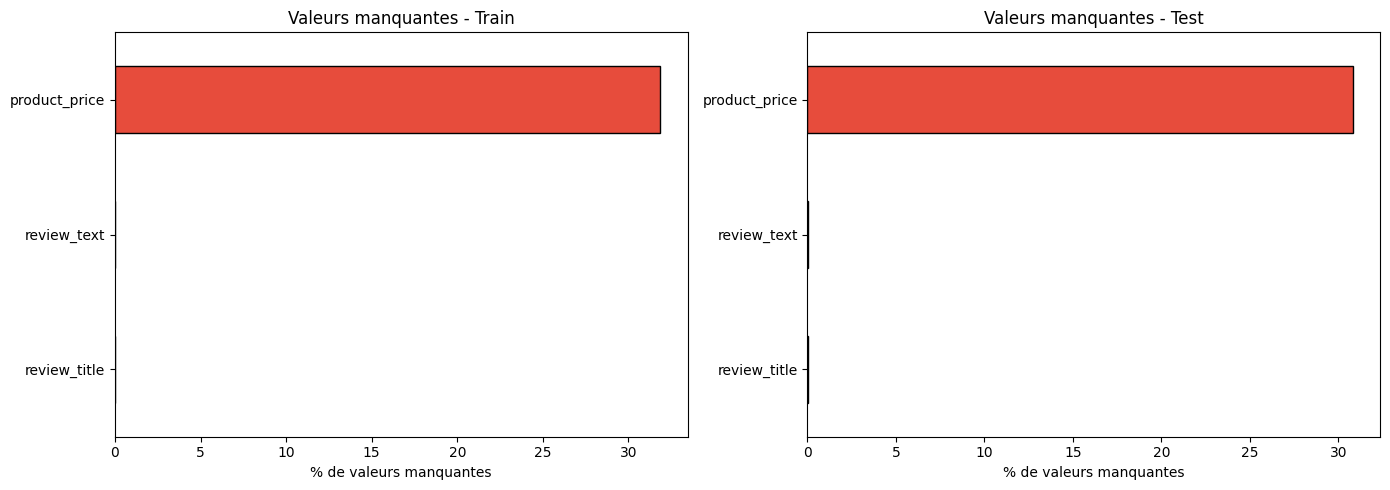

In [11]:
# Tableau des valeurs manquantes
def missing_analysis(df, name):
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    result = pd.DataFrame({'Manquantes': missing, '% Manquantes': missing_pct})
    result = result[result['Manquantes'] > 0].sort_values('% Manquantes', ascending=False)
    print(f"\n=== Valeurs manquantes ({name}) ===")
    if len(result) == 0:
        print("Aucune valeur manquante.")
    else:
        print(result)
    return result

missing_train = missing_analysis(df_train, 'Train')
missing_test = missing_analysis(df_test, 'Test')

# Visualisation des valeurs manquantes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df_tmp, title in [(axes[0], df_train, 'Train'), (axes[1], df_test, 'Test')]:
    missing_pct = (df_tmp.isnull().sum() / len(df_tmp) * 100)
    missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=True)
    if len(missing_pct) > 0:
        missing_pct.plot(kind='barh', ax=ax, color='#e74c3c', edgecolor='black')
        ax.set_xlabel('% de valeurs manquantes')
        ax.set_title(f'Valeurs manquantes - {title}')
    else:
        ax.text(0.5, 0.5, 'Aucune valeur manquante', ha='center', va='center', fontsize=12)
        ax.set_title(f'Valeurs manquantes - {title}')
plt.tight_layout()
plt.show()

In [12]:
# Impact des valeurs manquantes sur la cible
for col in ['review_text', 'product_description', 'review_title']:
    has_value = df_train[df_train[col].notna()]['review_score']
    no_value = df_train[df_train[col].isna()]['review_score']
    if len(no_value) > 0:
        print(f"\n{col} :")
        print(f"  Score moyen AVEC valeur  : {has_value.mean():.4f} (n={len(has_value)})")
        print(f"  Score moyen SANS valeur  : {no_value.mean():.4f} (n={len(no_value)})")
        print(f"  -> Différence : {abs(has_value.mean() - no_value.mean()):.4f}")
    else:
        print(f"\n{col} : aucune valeur manquante")


review_text :
  Score moyen AVEC valeur  : 4.2472 (n=79977)
  Score moyen SANS valeur  : 4.5217 (n=23)
  -> Différence : 0.2746

product_description : aucune valeur manquante

review_title :
  Score moyen AVEC valeur  : 4.2472 (n=79982)
  Score moyen SANS valeur  : 4.6111 (n=18)
  -> Différence : 0.3640


#### COMMENTAIRE D'ANALYSE - Valeurs manquantes
Nous avons d’abord analysé les valeurs manquantes pour voir si elles pouvaient influencer la variable cible review_score. Les variables review_text et review_title contiennent très peu de valeurs manquantes (moins de 0.05 %). Nous avons donc remplacé ces valeurs par des chaînes vides afin de conserver toutes les observations.

En revanche, la variable product_price contient davantage de valeurs manquantes (environ 32 %). Après conversion en format numérique, nous avons remplacé ces valeurs par la médiane, car cette mesure est moins sensible aux valeurs extrêmes que la moyenne.

### 3.3 Distribution de la variable cible (review_score)



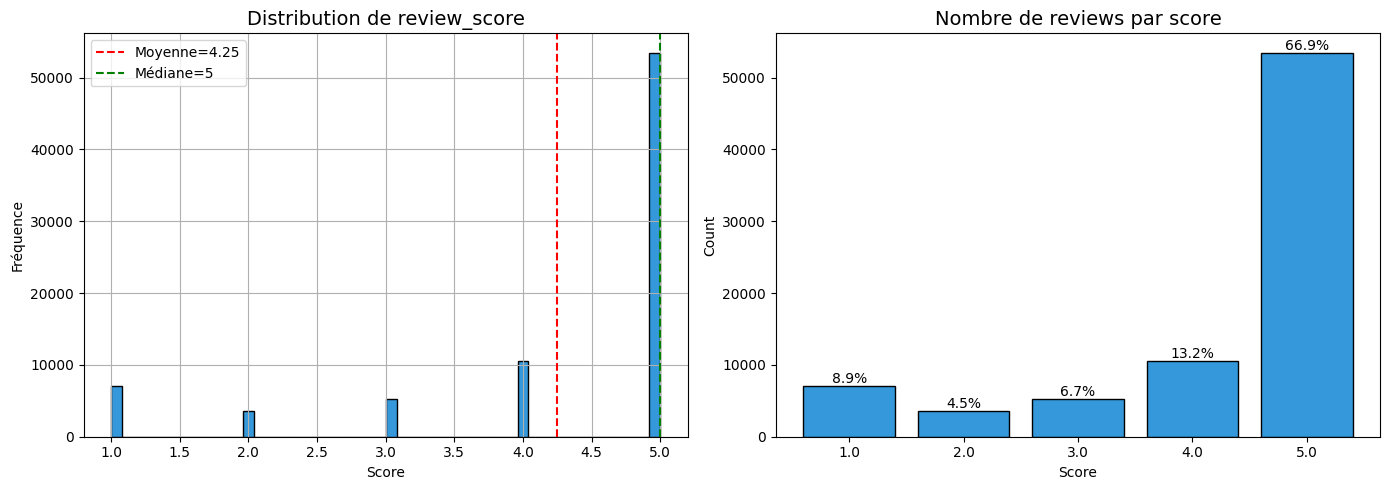

Moyenne des scores : 4.2472
Médiane des scores : 5.0000
Écart-type         : 1.2844
Skewness           : -1.5976
Kurtosis           : 1.1754


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
df_train['review_score'].hist(bins=50, ax=axes[0], color='#3498db', edgecolor='black')
axes[0].set_title('Distribution de review_score', fontsize=14)
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Fréquence')
axes[0].axvline(df_train['review_score'].mean(), color='red', linestyle='--', label=f"Moyenne={df_train['review_score'].mean():.2f}")
axes[0].axvline(df_train['review_score'].median(), color='green', linestyle='--', label=f"Médiane={df_train['review_score'].median():.0f}")
axes[0].legend()

# Bar plot par valeur entière
score_counts = df_train['review_score'].value_counts().sort_index()
axes[1].bar(score_counts.index.astype(str), score_counts.values, color='#3498db', edgecolor='black')
axes[1].set_title('Nombre de reviews par score', fontsize=14)
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Count')

# Annoter les pourcentages
for i, (score, count) in enumerate(score_counts.items()):
    pct = count / len(df_train) * 100
    axes[1].text(i, count + len(df_train)*0.005, f'{pct:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Moyenne des scores : {df_train['review_score'].mean():.4f}")
print(f"Médiane des scores : {df_train['review_score'].median():.4f}")
print(f"Écart-type         : {df_train['review_score'].std():.4f}")
print(f"Skewness           : {df_train['review_score'].skew():.4f}")
print(f"Kurtosis           : {df_train['review_score'].kurtosis():.4f}")

#### COMMENTAIRE D'ANALYSE - Distribution de la cible
Nous observons que la majorité des reviews ont une note élevée. Environ 80 % des observations ont un score de 4 ou 5, ce qui montre que la distribution est déséquilibrée. Les notes basses (1 et 2) sont beaucoup plus rares.

Cette situation peut influencer la modélisation. Un modèle simple pourrait avoir tendance à prédire des scores élevés, car ils sont les plus fréquents. Les notes basses étant peu nombreuses, le modèle aura moins d’exemples pour apprendre à les reconnaître.

Nous avons choisi de ne pas faire de rééchantillonnage, car ces techniques sont surtout adaptées aux problèmes de classification. Nous préférons utiliser des modèles basés sur le texte des reviews (TF-IDF) afin de capter des mots fortement associés aux avis négatifs, comme terrible ou worst, qui peuvent aider à mieux prédire les scores faibles.

### 3.4 Analyse du prix du produit

Prix - Q1: 14.99, Q3: 78.99, IQR: 64.00
Nombre d'outliers (prix) : 5798 (7.2%)
% prix manquants : 31.9%


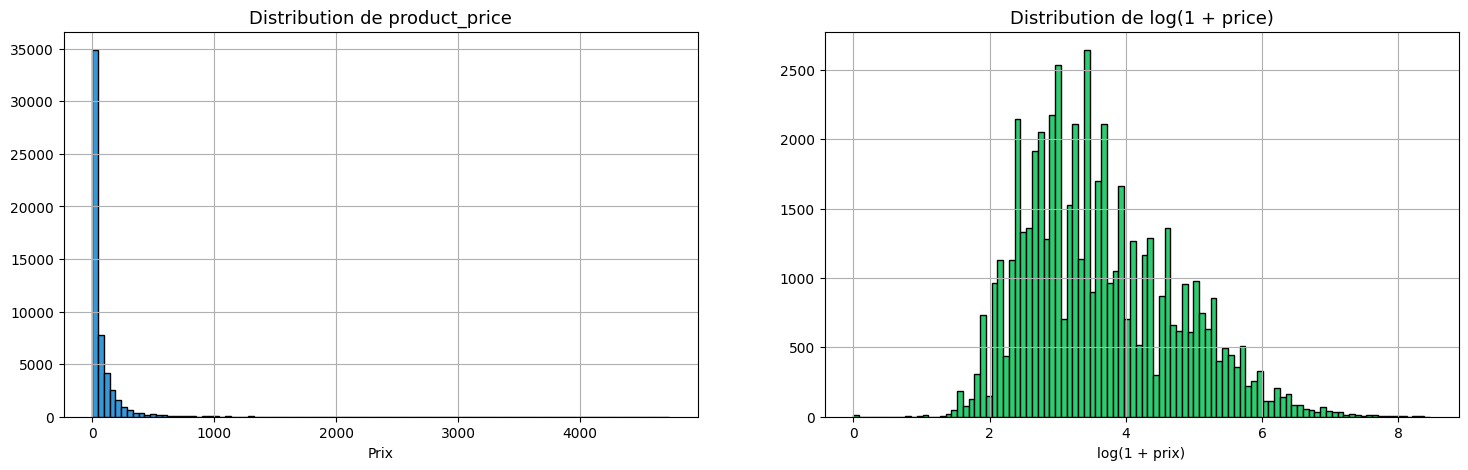

In [14]:
# --- Nettoyage / conversion prix en numérique ---
price_clean = (
    df_train["product_price"]
      .astype(str)
      .str.strip()
      .replace({"\"\"" : np.nan, "None": np.nan, "nan": np.nan})
      .str.replace(r"[^\d\.,-]", "", regex=True)
      .str.replace(",", ".", regex=False)
)
df_train["product_price_num"] = pd.to_numeric(price_clean, errors="coerce")
df_train.loc[df_train["product_price_num"] < 0, "product_price_num"] = np.nan

# --- Graphiques ---
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

df_train["product_price_num"].dropna().hist(bins=100, ax=axes[0], edgecolor="black", color="#3498db")
axes[0].set_title("Distribution de product_price", fontsize=13)
axes[0].set_xlabel("Prix")

np.log1p(df_train["product_price_num"].dropna().clip(lower=0)).hist(bins=100, ax=axes[1], edgecolor="black", color="#2ecc71")
axes[1].set_title("Distribution de log(1 + price)", fontsize=13)
axes[1].set_xlabel("log(1 + prix)")



# --- Statistiques outliers ---
price_series = df_train["product_price_num"].dropna()
q1 = price_series.quantile(0.25)
q3 = price_series.quantile(0.75)
iqr = q3 - q1
outliers = df_train[
    df_train["product_price_num"].notna() &
    ((df_train["product_price_num"] < q1 - 1.5*iqr) | (df_train["product_price_num"] > q3 + 1.5*iqr))
]
print(f"Prix - Q1: {q1:.2f}, Q3: {q3:.2f}, IQR: {iqr:.2f}")
print(f"Nombre d'outliers (prix) : {len(outliers)} ({len(outliers)/len(df_train)*100:.1f}%)")
print(f"% prix manquants : {df_train['product_price_num'].isna().mean()*100:.1f}%")

#### COMMENTAIRE D'ANALYSE - Prix

La variable product_price est très asymétrique. Nous avons appliqué log(1 + prix) pour stabiliser la distribution.

Nous avons détecté les valeurs extrêmes avec l’écart interquartile (IQR) : prix en dehors de [Q1 − 1.5×IQR, Q3 + 1.5×IQR]. Ces outliers (~7 %) correspondent probablement à des produits haut de gamme légitimes et ont été conservés.

Enfin, les 31.9 % de prix manquants ont été remplacés par la médiane. Le prix reste une information contextuelle, même si sa corrélation avec le score est faible.

### 3.5 Analyse des textes (longueurs, corrélations)

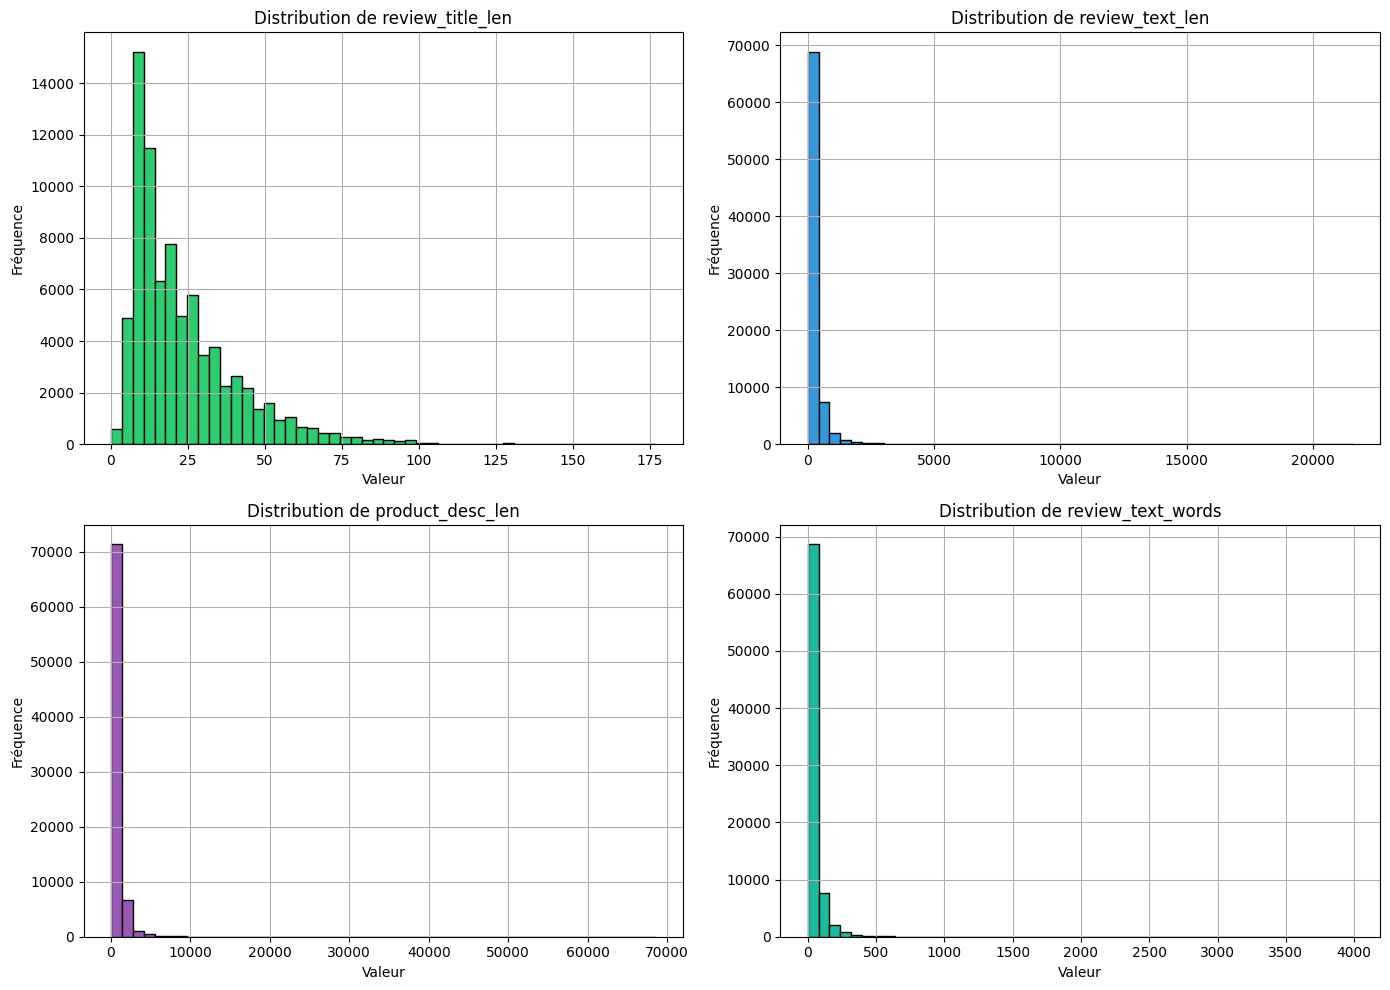


=== Corrélations avec review_score ===
  review_title_len          : -0.0958
  review_text_len           : -0.0833
  product_desc_len          : -0.0115
  review_text_words         : -0.0865
  product_price_num         : +0.0091


In [15]:
# Calculer les longueurs
df_train['review_title_len'] = df_train['review_title'].fillna('').apply(len)
df_train['review_text_len'] = df_train['review_text'].fillna('').apply(len)
df_train['product_desc_len'] = df_train['product_description'].fillna('').apply(len)
df_train['review_text_words'] = df_train['review_text'].fillna('').apply(lambda x: len(x.split()))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col, color in zip(axes.flatten(), 
    ['review_title_len', 'review_text_len', 'product_desc_len', 'review_text_words'],
    ['#2ecc71', '#3498db', '#9b59b6', '#1abc9c']):
    df_train[col].hist(bins=50, ax=ax, color=color, edgecolor='black')
    ax.set_title(f'Distribution de {col}', fontsize=12)
    ax.set_xlabel('Valeur')
    ax.set_ylabel('Fréquence')
plt.tight_layout()
plt.show()

# --- Corrélations ---
price_clean = (
    df_train["product_price"]
      .astype(str).str.strip()
      .str.replace(r"from\s*", "", regex=True)
      .str.replace(r"[^\d\.,-]", "", regex=True)
      .str.replace(",", ".", regex=False)
)
df_train["product_price_num"] = pd.to_numeric(price_clean, errors="coerce")

print("\n=== Corrélations avec review_score ===")
corr_cols = ['review_title_len', 'review_text_len', 'product_desc_len', 'review_text_words', 'product_price_num']
subset = df_train[corr_cols + ['review_score']].dropna()
for col in corr_cols:
    corr = subset[col].corr(subset['review_score'])
    print(f"  {col:25s} : {corr:+.4f}")

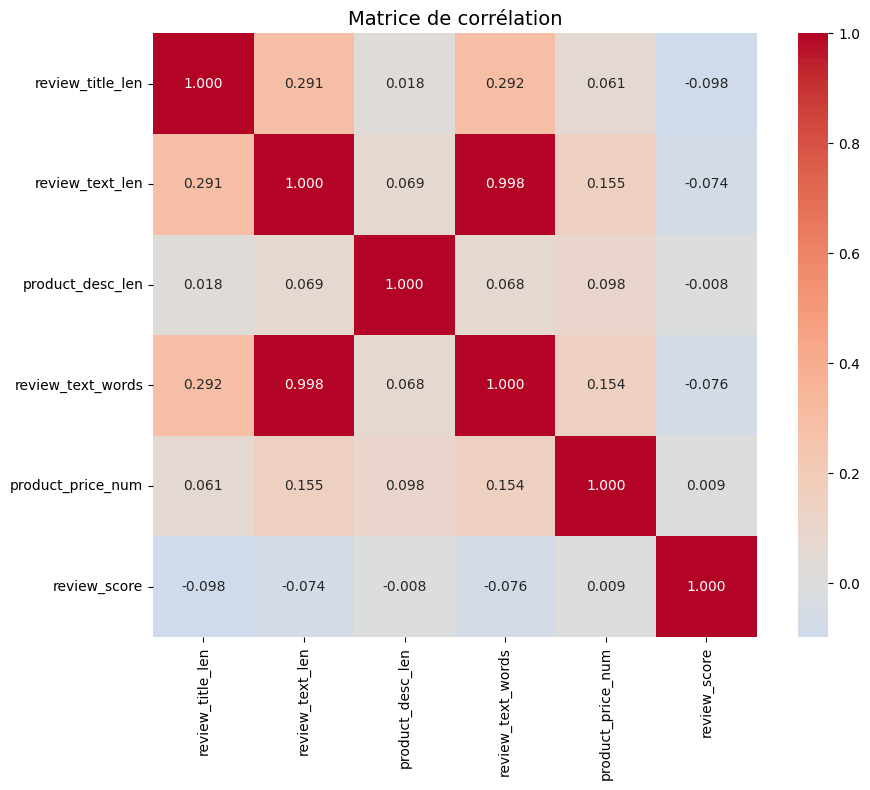

In [16]:
# Matrice de corrélation
corr_data = df_train[corr_cols + ['review_score']].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_data, annot=True, fmt='.3f', cmap='coolwarm', center=0, ax=ax, square=True)
ax.set_title('Matrice de corrélation', fontsize=14)
plt.tight_layout()
plt.show()

#### COMMENTAIRE D'ANALYSE - Textes et corrélations

Les corrélations linéaires entre les features numériques (longueur du texte, nombre de mots, prix) et review_score sont très faibles (|r| < 0.1). Les avis longs ont une légère tendance à être plus critiques, et certaines features sont redondantes (review_text_len et review_text_words, corrélation ~0.99).

Conclusion : le signal utile n’est pas dans “combien le texte est long”, mais dans ce que le texte dit. C’est pour cela que nous utilisons TF-IDF, afin de capturer des mots ou expressions comme :

excellent

waste of money

not good

high quality

---
## 4. Prétraitement



In [17]:
import pandas as pd
import numpy as np
import re

def clean_text(text):
    """Nettoyage basique d'un texte.
  
    - Mise en minuscule
    - Suppression des URLs et HTML
    - Suppression des caractères spéciaux
    - Normalisation des espaces
    """
    if pd.isna(text):
        return ''
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()


def preprocess_dataframe(df):
    df = df.copy()
    
    # --- Texte manquant ---
    df['review_title']        = df['review_title'].fillna('')
    df['review_text']         = df['review_text'].fillna('')
    df['product_description'] = df['product_description'].fillna('')
    
    # --- Nettoyage prix ---
    price_clean = (
        df["product_price"]
        .astype(str).str.strip()
        .replace({"": np.nan, "None": np.nan, "nan": np.nan})
        .str.replace(r"from\s*", "", regex=True)
        .str.replace(r"[^\d\.,-]", "", regex=True)
        .str.replace(",", ".", regex=False)
    )
    df["product_price_num"] = pd.to_numeric(price_clean, errors="coerce")
    df["product_price_num"] = df["product_price_num"].fillna(df["product_price_num"].median())
    
    # --- Nettoyage texte ---
    df['review_title_clean']        = df['review_title'].apply(clean_text)
    df['review_text_clean']         = df['review_text'].apply(clean_text)
    df['product_description_clean'] = df['product_description'].apply(clean_text)
    
    # --- Longueurs et compte de mots ---
    df['title_len']       = df['review_title_clean'].apply(len)
    df['text_len']        = df['review_text_clean'].apply(len)
    df['desc_len']        = df['product_description_clean'].apply(len)
    df['title_word_count'] = df['review_title_clean'].apply(lambda x: len(x.split()))
    df['text_word_count']  = df['review_text_clean'].apply(lambda x: len(x.split()))
    df['desc_word_count']  = df['product_description_clean'].apply(lambda x: len(x.split()))
    
    # --- Flags présence texte/description ---
    df['has_review_text'] = (df['review_text_clean'].str.len() > 0).astype(int)
    df['has_description'] = (df['product_description_clean'].str.len() > 0).astype(int)
    
    # --- Log transformation prix ---
    df['log_price'] = np.log1p(df['product_price_num'].clip(lower=0))
    
    # --- Texte combiné pour TF-IDF ---
    df['all_text'] = (
        df['review_title_clean'] + ' ' +
        df['review_text_clean'] + ' ' +
        df['product_description_clean']
    )
    
    return df


# --- Application ---
print("Prétraitement train...")
df_train_processed = preprocess_dataframe(df_train)

print("Prétraitement test...")
df_test_processed = preprocess_dataframe(df_test)

print(f"Train : {df_train_processed.shape} | Test : {df_test_processed.shape}")
print("Valeurs manquantes restantes :",
      df_train_processed[['review_text_clean','log_price']].isnull().sum().to_dict())

Prétraitement train...
Prétraitement test...
Train : (80000, 24) | Test : (20000, 19)
Valeurs manquantes restantes : {'review_text_clean': 0, 'log_price': 0}


---
## 5. Baseline et fonction d'évaluation

La baseline (prédire la moyenne) donne le **plancher** à battre.

In [18]:
y_train = df_train_processed['review_score'].values

X_tmp_tr, X_tmp_val, y_tmp_tr, y_tmp_val = train_test_split(
    np.zeros((len(y_train),1)), y_train, test_size=0.2, random_state=RANDOM_STATE
)

mean_score    = y_tmp_tr.mean()
baseline_mse  = mean_squared_error(y_tmp_val, np.full(len(y_tmp_val), mean_score))
print(f"Baseline MSE (prédire la moyenne {mean_score:.3f}) = {baseline_mse:.4f}")
print(f"→ Tout modèle sérieux doit être bien en dessous de {baseline_mse:.2f}")

def evaluate(name, y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    print(f"  {name:<45s} MSE={mse:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}")
    return mse

Baseline MSE (prédire la moyenne 4.242) = 1.6035
→ Tout modèle sérieux doit être bien en dessous de 1.60


Notre objectif est donc de faire mieux que ce modèle 

---
## 6. Stemming + Stopwords 
**Stemming :** réduit chaque mot à sa racine morphologique ("amazingly" → "amaz", "disappointed" → "disappoint"). Cela regroupe les variantes d'un même mot et augmente leur fréquence TF dans le corpus.

**Stopwords :** on retire les mots sans valeur discriminante ("the", "a", "is"...) **sauf les négations** ("not", "never", "hardly") qui inversent le sentiment et sont cruciales.

In [19]:
if NLTK_AVAILABLE:
    stemmer   = SnowballStemmer('english')
    stop_words = set(stopwords.words('english'))
    # Conservation des négations — elles inversent le sentiment
    negations = {'no','not','nor','never','nobody','nothing','neither',
                 'nowhere','hardly','barely','scarcely'}
    stop_words -= negations
    print(f"Stopwords chargés : {len(stop_words)} mots (négations conservées : {len(negations)})")

    def clean_and_stem(text):
        if pd.isna(text) or text == '': return ''
        text = str(text).lower()
        text = re.sub(r'http\S+|www\S+', '', text)
        text = re.sub(r'<.*?>', '', text)
        text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
        text = re.sub(r'\s+', ' ', text).strip()
        tokens = [stemmer.stem(t) for t in text.split()
                  if t not in stop_words and len(t) > 1]
        return ' '.join(tokens)
else:
    clean_and_stem = clean_text
    print("Fallback : pas de stemming (NLTK absent)")

sample = "This product is absolutely amazing! I loved it, not disappointed at all."
print(f"\nOriginal : {sample}")
print(f"Stemmé   : {clean_and_stem(sample)}")

Stopwords chargés : 195 mots (négations conservées : 11)

Original : This product is absolutely amazing! I loved it, not disappointed at all.
Stemmé   : product absolut amaz love not disappoint


In [20]:
print("Application stemming sur train et test (peut prendre 1-2 min)...")

df_train_v3 = df_train_processed.copy()
df_test_v3  = df_test_processed.copy()

df_train_v3['review_text_stem']  = df_train_v3['review_text'].apply(clean_and_stem)
df_train_v3['review_title_stem'] = df_train_v3['review_title'].apply(clean_and_stem)
df_train_v3['product_desc_stem'] = df_train_v3['product_description'].apply(clean_and_stem)
df_test_v3['review_text_stem']   = df_test_v3['review_text'].apply(clean_and_stem)
df_test_v3['review_title_stem']  = df_test_v3['review_title'].apply(clean_and_stem)
df_test_v3['product_desc_stem']  = df_test_v3['product_description'].apply(clean_and_stem)

print(f"Exemple (review_text) :")
print(f"  Original : {df_train_v3['review_text'].iloc[0][:120]}")
print(f"  Stemmé   : {df_train_v3['review_text_stem'].iloc[0][:120]}")
print("Stemming terminé !")

Application stemming sur train et test (peut prendre 1-2 min)...
Exemple (review_text) :
  Original : This is the best capo I've ever had.
  Stemmé   : best capo ever
Stemming terminé !


---
## 7. Features VADER complet (7500 mots)





Nous avons choisi d'utiliser la librairie **VADER** (Valence Aware Dictionary and sEntiment Reasoner) pour extraire un signal de sentiment directement à partir du texte. VADER repose sur un lexique de **7 500 mots** avec des valences calibrées sur des annotations humaines réelles : chaque mot a une valence de -3 (très négatif) à +3 (très positif), les intensificateurs ("very", "extremely") amplifient cette valence, et les négations ("not", "never") inversent le signe.

Nous avons décidé de calculer ces scores séparément sur le texte de la review et sur le titre, ce qui nous donne **7 features de sentiment** au total : un score global `compound` (entre -1 et +1) et trois ratios `pos`, `neg`, `neu` pour chaque champ. 

In [5]:
vader_analyzer = SentimentIntensityAnalyzer()

def add_vader_features(df):
    df = df.copy()

    # VADER sur le texte de la review
    vader_text = df['review_text'].apply(
        lambda x: vader_analyzer.polarity_scores(str(x) if pd.notna(x) else '')
    )
    df['vader_compound'] = vader_text.apply(lambda x: x['compound'])
    df['vader_pos']      = vader_text.apply(lambda x: x['pos'])
    df['vader_neg']      = vader_text.apply(lambda x: x['neg'])
    df['vader_neu']      = vader_text.apply(lambda x: x['neu'])

    # VADER sur le titre
    vader_title = df['review_title'].apply(
        lambda x: vader_analyzer.polarity_scores(str(x) if pd.notna(x) else '')
    )
    df['vader_title_compound'] = vader_title.apply(lambda x: x['compound'])
    df['vader_title_pos']      = vader_title.apply(lambda x: x['pos'])
    df['vader_title_neg']      = vader_title.apply(lambda x: x['neg'])

    # Features texte enrichies
    df['exclamation_count'] = df['review_text'].fillna('').str.count('!')
    df['question_count']    = df['review_text'].fillna('').str.count('\\?')
    df['negation_count']    = df['review_text'].fillna('').str.lower().str.count(
                                  r'\b(?:not|never|no|hardly|barely)\b')
    df['caps_ratio']        = df['review_text'].fillna('').apply(
                                  lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1))
    df['digit_count']       = df['review_text'].fillna('').str.count(r'\d')
    df['stars_mention']     = df['review_text'].fillna('').str.lower().str.count(
                                  r'\b(?:star|stars|rating|rated)\b')
    # Ratio title/text (titre long = avis impliqué)
    df['title_text_ratio']  = df['title_word_count'] / (df['text_word_count'] + 1)
    # Densité de sentiment
    df['sentiment_density'] = df['vader_compound'].abs() / (df['text_word_count'] + 1)

    return df

print('Calcul features VADER complet...')
df_train_v4 = add_vader_features(df_train_v4)
df_test_v4  = add_vader_features(df_test_v4)

print('\n=== Corrélations VADER avec review_score ===')
vader_cols = ['vader_compound','vader_pos','vader_neg','vader_title_compound',
              'vader_title_pos','vader_title_neg']
for col in vader_cols:
    corr = df_train_v4[col].corr(df_train_v4['review_score'])
    print(f'  {col:30s} : {corr:+.4f}')

print('\n=== VADER compound moyen par note ===')
for s in [1,2,3,4,5]:
    mask = df_train_v4['review_score'] == s
    print(f'  Note {s} : {df_train_v4.loc[mask,"vader_compound"].mean():+.3f}  (n={mask.sum()})')

Calcul features VADER complet...

=== Corrélations VADER avec review_score ===
  vader_compound                 : +0.5303
  vader_pos                      : +0.3936
  vader_neg                      : -0.4325
  vader_title_compound           : +0.4738
  vader_title_pos                : +0.3652
  vader_title_neg                : -0.4512

=== VADER compound moyen par note ===
  Note 1 : -0.115  (n=7088)
  Note 2 : +0.070  (n=3566)
  Note 3 : +0.268  (n=5321)
  Note 4 : +0.548  (n=10529)
  Note 5 : +0.644  (n=53496)


---
## 8. TF-IDF  — 4 vectoriseurs séparés 


Nous avons choisi de vectoriser les champs texte séparément plutôt que de les concaténer, afin que le modèle sache d'où provient chaque mot. Un mot dans le titre d'une review porte en effet une information bien plus forte que le même mot dans la description produit. Nous utilisons donc **4 vectoriseurs TF-IDF distincts** : un sur le texte de la review, un sur le titre, un sur la description, et un dernier sur les caractères n-grammes pour capturer les fautes d'orthographe et les intensificateurs ("sooo good"). L'ensemble représente **95 000 features** au total.

In [6]:
print('=== Construction TF-IDF (fit uniquement sur TRAIN) ===')

tfidf_review = TfidfVectorizer(max_features=60000, ngram_range=(1,3),
    min_df=2, max_df=0.95, sublinear_tf=True, strip_accents='unicode')
tfidf_title  = TfidfVectorizer(max_features=10000, ngram_range=(1,2),
    min_df=2, max_df=0.95, sublinear_tf=True, strip_accents='unicode')
tfidf_desc   = TfidfVectorizer(max_features=5000,  ngram_range=(1,1),
    min_df=3, max_df=0.95, sublinear_tf=True, strip_accents='unicode')
tfidf_char   = TfidfVectorizer(max_features=20000, ngram_range=(3,5),
    analyzer='char_wb', min_df=5, max_df=0.95, sublinear_tf=True)

print('tfidf_review...')
Xtr_rev = tfidf_review.fit_transform(df_train_v4['review_text_stem'])
Xte_rev = tfidf_review.transform(df_test_v4['review_text_stem'])

print('tfidf_title...')
Xtr_ttl = tfidf_title.fit_transform(df_train_v4['review_title_stem'])
Xte_ttl = tfidf_title.transform(df_test_v4['review_title_stem'])

print('tfidf_desc...')
Xtr_dsc = tfidf_desc.fit_transform(df_train_v4['product_desc_stem'])
Xte_dsc = tfidf_desc.transform(df_test_v4['product_desc_stem'])

print('tfidf_char...')
Xtr_chr = tfidf_char.fit_transform(df_train_v4['review_text'].fillna(''))
Xte_chr = tfidf_char.transform(df_test_v4['review_text'].fillna(''))

print(f'\nTF-IDF total : {Xtr_rev.shape[1]+Xtr_ttl.shape[1]+Xtr_dsc.shape[1]+Xtr_chr.shape[1]} features')

=== Construction TF-IDF (fit uniquement sur TRAIN) ===
tfidf_review...
tfidf_title...
tfidf_desc...
tfidf_char...

TF-IDF total : 95000 features


---
## 9. Sentence Embeddings — `all-MiniLM-L6-v2`





Nous avons décidé d'enrichir notre représentation textuelle avec des **embeddings de phrases** produits par le modèle pré-entraîné `all-MiniLM-L6-v2`. Contrairement au TF-IDF qui traite chaque mot indépendamment, ce modèle encode le **sens réel** du texte en un vecteur dense de 384 dimensions. Il a été entraîné sur des millions de phrases et sait donc que "amazing" et "fantastic" expriment la même chose, ou que "not good" est une expression négative malgré la présence du mot "good". Nous avons choisi d'encoder séparément le texte de la review et le titre, ce qui produit **768 dimensions denses** par observation, qui serviront d'input à LightGBM et XGBoost.

In [7]:
print('Chargement du modèle sentence-transformers...')
print('(téléchargement ~80MB au premier lancement)')
sbert = SentenceTransformer('all-MiniLM-L6-v2')
print('Modèle chargé !')

# On encode review_text + review_title (les plus informatifs)
# La description produit est moins utile et ralentirait l'encodage
print('\nEncodage review_text (train)... (~5-10 min)')
train_text_emb = sbert.encode(
    df_train_v4['review_text'].fillna('').tolist(),
    batch_size=256,
    show_progress_bar=True,
    normalize_embeddings=True
)

print('\nEncodage review_text (test)...')
test_text_emb = sbert.encode(
    df_test_v4['review_text'].fillna('').tolist(),
    batch_size=256,
    show_progress_bar=True,
    normalize_embeddings=True
)

print('\nEncodage review_title (train)...')
train_title_emb = sbert.encode(
    df_train_v4['review_title'].fillna('').tolist(),
    batch_size=512,
    show_progress_bar=True,
    normalize_embeddings=True
)

print('\nEncodage review_title (test)...')
test_title_emb = sbert.encode(
    df_test_v4['review_title'].fillna('').tolist(),
    batch_size=512,
    show_progress_bar=True,
    normalize_embeddings=True
)

print(f'\nEmbeddings review_text : {train_text_emb.shape}')
print(f'Embeddings review_title: {train_title_emb.shape}')

# Concaténer les embeddings
Xtr_emb = np.hstack([train_text_emb, train_title_emb])
Xte_emb = np.hstack([test_text_emb, test_title_emb])
print(f'Embeddings combinés   : {Xtr_emb.shape}')

Chargement du modèle sentence-transformers...
(téléchargement ~80MB au premier lancement)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...


Encodage review_title (train)...


Batches:   0%|          | 0/157 [00:00<?, ?it/s]


Encodage review_title (test)...


Batches:   0%|          | 0/40 [00:00<?, ?it/s]


Embeddings review_text : (80000, 384)
Embeddings review_title: (80000, 384)
Embeddings combinés   : (80000, 768)


---
## 10. Features numériques enrichies

In [8]:
num_cols = [
    # Longueurs
    'title_len', 'text_len', 'desc_len',
    'title_word_count', 'text_word_count', 'desc_word_count',
    # Flags
    'has_review_text', 'has_description',
    # Prix
    'product_price_num', 'log_price',
    # VADER complet
    'vader_compound', 'vader_pos', 'vader_neg', 'vader_neu',
    'vader_title_compound', 'vader_title_pos', 'vader_title_neg',
    # Features texte enrichies
    'exclamation_count', 'question_count', 'negation_count',
    'caps_ratio', 'digit_count', 'stars_mention',
    'title_text_ratio', 'sentiment_density',
]
num_cols = [c for c in num_cols if c in df_train_v4.columns]

Xtr_num = df_train_v4[num_cols].apply(pd.to_numeric, errors='coerce')
Xte_num = df_test_v4[num_cols].apply(pd.to_numeric, errors='coerce')
median_vals = Xtr_num.median()
Xtr_num = Xtr_num.fillna(median_vals)
Xte_num = Xte_num.fillna(median_vals)

scaler = StandardScaler()
Xtr_num_s = scaler.fit_transform(Xtr_num)
Xte_num_s = scaler.transform(Xte_num)

print(f'Features numériques : {len(num_cols)}')
print(f'Colonnes : {num_cols}')

Features numériques : 25
Colonnes : ['title_len', 'text_len', 'desc_len', 'title_word_count', 'text_word_count', 'desc_word_count', 'has_review_text', 'has_description', 'product_price_num', 'log_price', 'vader_compound', 'vader_pos', 'vader_neg', 'vader_neu', 'vader_title_compound', 'vader_title_pos', 'vader_title_neg', 'exclamation_count', 'question_count', 'negation_count', 'caps_ratio', 'digit_count', 'stars_mention', 'title_text_ratio', 'sentiment_density']


---
## 11. Construction des matrices finales

On crée **deux matrices** :
- `X_tfidf` : TF-IDF sparse + features numériques → pour Ridge, SVR
- `X_dense` : embeddings + features numériques → pour LightGBM, XGBoost (qui préfèrent le dense)

In [10]:
y_train = df_train_v4['review_score'].values

# Matrice sparse (TF-IDF + numériques) pour Ridge/SVR — reste en sparse, pas de MemoryError
X_tfidf_train = hstack([Xtr_rev, Xtr_ttl, Xtr_dsc, Xtr_chr, csr_matrix(Xtr_num_s)])
X_tfidf_test  = hstack([Xte_rev, Xte_ttl, Xte_dsc, Xte_chr, csr_matrix(Xte_num_s)])

# Matrice dense (embeddings SBERT + numériques) pour LightGBM/XGBoost
# ~800 colonnes seulement → OK en RAM
X_dense_train = np.hstack([Xtr_emb, Xtr_num_s])
X_dense_test  = np.hstack([Xte_emb, Xte_num_s])

print(f'X_tfidf_train : {X_tfidf_train.shape}  (sparse)')
print(f'X_dense_train : {X_dense_train.shape}  (dense)')
print(f'Mémoire dense : ~{X_dense_train.nbytes / 1e6:.0f} MB')

X_tfidf_train : (80000, 95025)  (sparse)
X_dense_train : (80000, 793)  (dense)
Mémoire dense : ~508 MB




## 12. Tuning rapide des hyperparamètres (split 80/20)

Avant de lancer le stacking OOF complet qui est coûteux en temps de calcul, nous avons décidé d'effectuer un **tuning rapide des hyperparamètres** sur un simple split 80/20. L'idée est de trouver les meilleures valeurs pour chaque modèle (alpha pour Ridge, C pour LinearSVR, n_estimators et learning_rate pour LightGBM et XGBoost) avant de les fixer définitivement pour le stacking. Cela nous permet d'éviter de lancer 5 folds complets pour chaque combinaison d'hyperparamètres, ce qui serait beaucoup trop long.

In [11]:
idx_tr, idx_val = train_test_split(np.arange(len(y_train)),
                                    test_size=0.2, random_state=RANDOM_STATE)

Xq_tfidf_tr, Xq_tfidf_val = X_tfidf_train[idx_tr], X_tfidf_train[idx_val]
Xq_dense_tr, Xq_dense_val = X_dense_train[idx_tr], X_dense_train[idx_val]
yq_tr, yq_val = y_train[idx_tr], y_train[idx_val]

# --- Ridge ---
best_alpha_ridge, best_mse_ridge = None, float('inf')
print('Tuning Ridge...')
for a in [1.0, 5.0, 10.0, 20.0, 50.0]:
    m = Ridge(alpha=a)
    m.fit(Xq_tfidf_tr, yq_tr)
    mse = mean_squared_error(yq_val, m.predict(Xq_tfidf_val))
    print(f'  Ridge alpha={a:5.1f} → MSE={mse:.4f}')
    if mse < best_mse_ridge: best_mse_ridge=mse; best_alpha_ridge=a

# --- LinearSVR ---
best_C_svr, best_mse_svr = None, float('inf')
print('\nTuning LinearSVR...')
for C in [0.01, 0.05, 0.1, 0.5]:
    m = LinearSVR(C=C, max_iter=20000, random_state=RANDOM_STATE,
                  loss='squared_epsilon_insensitive')
    m.fit(Xq_tfidf_tr, yq_tr)
    mse = mean_squared_error(yq_val, m.predict(Xq_tfidf_val))
    print(f'  SVR C={C:.3f} → MSE={mse:.4f}')
    if mse < best_mse_svr: best_mse_svr=mse; best_C_svr=C

# --- LightGBM ---
best_params_lgb, best_mse_lgb = None, float('inf')
print('\nTuning LightGBM...')
for n_est, lr, num_leaves in [(500, 0.05, 63), (1000, 0.03, 127), (800, 0.05, 63)]:
    m = lgb.LGBMRegressor(n_estimators=n_est, learning_rate=lr, num_leaves=num_leaves,
                           min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
                           reg_alpha=0.1, reg_lambda=1.0, random_state=RANDOM_STATE,
                           n_jobs=-1, verbose=-1)
    m.fit(Xq_dense_tr, yq_tr,
          eval_set=[(Xq_dense_val, yq_val)],
          callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(False)])
    mse = mean_squared_error(yq_val, m.predict(Xq_dense_val))
    print(f'  LGB n={n_est} lr={lr} leaves={num_leaves} → MSE={mse:.4f}')
    if mse < best_mse_lgb:
        best_mse_lgb = mse
        best_params_lgb = {'n_estimators': n_est, 'learning_rate': lr, 'num_leaves': num_leaves}

# --- XGBoost ---
best_params_xgb, best_mse_xgb = None, float('inf')
print('\nTuning XGBoost...')
for n_est, lr, max_depth in [(500, 0.05, 6), (800, 0.05, 8)]:
    m = xgb.XGBRegressor(n_estimators=n_est, learning_rate=lr, max_depth=max_depth,
                          subsample=0.8, colsample_bytree=0.8,
                          reg_alpha=0.1, reg_lambda=1.0, random_state=RANDOM_STATE,
                          n_jobs=-1, verbosity=0, early_stopping_rounds=50,
                          eval_metric='rmse')
    m.fit(Xq_dense_tr, yq_tr, eval_set=[(Xq_dense_val, yq_val)], verbose=False)
    mse = mean_squared_error(yq_val, m.predict(Xq_dense_val))
    print(f'  XGB n={n_est} lr={lr} depth={max_depth} → MSE={mse:.4f}')
    if mse < best_mse_xgb:
        best_mse_xgb = mse
        best_params_xgb = {'n_estimators': n_est, 'learning_rate': lr, 'max_depth': max_depth}

print('\n=== Résumé tuning ===')
print(f'  Ridge  alpha={best_alpha_ridge}  → MSE={best_mse_ridge:.4f}')
print(f'  SVR    C={best_C_svr}    → MSE={best_mse_svr:.4f}')
print(f'  LGB    {best_params_lgb} → MSE={best_mse_lgb:.4f}')
print(f'  XGB    {best_params_xgb} → MSE={best_mse_xgb:.4f}')

Tuning Ridge...
  Ridge alpha=  1.0 → MSE=0.5378
  Ridge alpha=  5.0 → MSE=0.5001
  Ridge alpha= 10.0 → MSE=0.5051
  Ridge alpha= 20.0 → MSE=0.5199
  Ridge alpha= 50.0 → MSE=0.5540

Tuning LinearSVR...
  SVR C=0.010 → MSE=0.5543
  SVR C=0.050 → MSE=0.5051
  SVR C=0.100 → MSE=0.5000
  SVR C=0.500 → MSE=0.5379

Tuning LightGBM...
  LGB n=500 lr=0.05 leaves=63 → MSE=0.5084
  LGB n=1000 lr=0.03 leaves=127 → MSE=0.5012
  LGB n=800 lr=0.05 leaves=63 → MSE=0.5039

Tuning XGBoost...
  XGB n=500 lr=0.05 depth=6 → MSE=0.5153
  XGB n=800 lr=0.05 depth=8 → MSE=0.5102

=== Résumé tuning ===
  Ridge  alpha=5.0  → MSE=0.5001
  SVR    C=0.1    → MSE=0.5000
  LGB    {'n_estimators': 1000, 'learning_rate': 0.03, 'num_leaves': 127} → MSE=0.5012
  XGB    {'n_estimators': 800, 'learning_rate': 0.05, 'max_depth': 8} → MSE=0.5102


## 13. Stacking OOF 5-folds — 4 modèles de base

Une fois les hyperparamètres fixés, nous avons mis en place le **stacking Out-Of-Fold** qui constitue le cœur de notre TRAVAIL. Le principe est le suivant : on divise le train en 5 folds, et pour chaque fold, chaque modèle est entraîné sur les 4 autres folds et prédit sur le fold restant. Ainsi, chaque observation est prédite par un modèle qui ne l'a jamais vue pendant son entraînement, ce qui garantit l'absence de data leakage. Nous avons retenu **4 modèles de base** aux approches complémentaires : Ridge et LinearSVR qui travaillent sur la matrice TF-IDF sparse, et LightGBM et XGBoost qui travaillent sur les embeddings SBERT denses. À l'issue des 5 folds, nous disposons de prédictions OOF pour l'ensemble des 80 000 observations, qui serviront de features au méta-modèle.

In [13]:
print('=== Stacking OOF 5 folds — 4 modèles ===')
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
n_test = X_tfidf_test.shape[0]

oof_ridge  = np.zeros(len(y_train))
oof_svr    = np.zeros(len(y_train))
oof_lgb    = np.zeros(len(y_train))
oof_xgb    = np.zeros(len(y_train))

test_ridge_folds = np.zeros((n_test, 5))
test_svr_folds   = np.zeros((n_test, 5))
test_lgb_folds   = np.zeros((n_test, 5))
test_xgb_folds   = np.zeros((n_test, 5))

for fold, (idx_tr, idx_val) in enumerate(kf.split(X_tfidf_train)):
    print(f'\n--- Fold {fold+1}/5 ---')

    Xktr_tfidf  = X_tfidf_train[idx_tr]
    Xkval_tfidf = X_tfidf_train[idx_val]
    Xktr_dense  = X_dense_train[idx_tr]
    Xkval_dense = X_dense_train[idx_val]
    yktr  = y_train[idx_tr]
    ykval = y_train[idx_val]

    # Ridge
    print('  Ridge...', end='')
    m_r = Ridge(alpha=best_alpha_ridge)
    m_r.fit(Xktr_tfidf, yktr)
    oof_ridge[idx_val]       = m_r.predict(Xkval_tfidf)
    test_ridge_folds[:,fold] = m_r.predict(X_tfidf_test)
    print(f' MSE={mean_squared_error(ykval, oof_ridge[idx_val]):.4f}')

    # LinearSVR
    print('  LinearSVR...', end='')
    m_s = LinearSVR(C=best_C_svr, max_iter=20000, random_state=RANDOM_STATE,
                    loss='squared_epsilon_insensitive')
    m_s.fit(Xktr_tfidf, yktr)
    oof_svr[idx_val]       = m_s.predict(Xkval_tfidf)
    test_svr_folds[:,fold] = m_s.predict(X_tfidf_test)
    print(f' MSE={mean_squared_error(ykval, oof_svr[idx_val]):.4f}')

    # LightGBM
    print('  LightGBM...', end='')
    m_l = lgb.LGBMRegressor(
        **best_params_lgb,
        min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0, random_state=RANDOM_STATE,
        n_jobs=-1, verbose=-1
    )
    m_l.fit(Xktr_dense, yktr,
            eval_set=[(Xkval_dense, ykval)],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(False)])
    oof_lgb[idx_val]       = m_l.predict(Xkval_dense)
    test_lgb_folds[:,fold] = m_l.predict(X_dense_test)
    print(f' MSE={mean_squared_error(ykval, oof_lgb[idx_val]):.4f}')

    # XGBoost
    print('  XGBoost...', end='')
    m_x = xgb.XGBRegressor(
        **best_params_xgb,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0, random_state=RANDOM_STATE,
        n_jobs=-1, verbosity=0, early_stopping_rounds=50, eval_metric='rmse'
    )
    m_x.fit(Xktr_dense, yktr, eval_set=[(Xkval_dense, ykval)], verbose=False)
    oof_xgb[idx_val]       = m_x.predict(Xkval_dense)
    test_xgb_folds[:,fold] = m_x.predict(X_dense_test)
    print(f' MSE={mean_squared_error(ykval, oof_xgb[idx_val]):.4f}')

test_ridge_oof = test_ridge_folds.mean(axis=1)
test_svr_oof   = test_svr_folds.mean(axis=1)
test_lgb_oof   = test_lgb_folds.mean(axis=1)
test_xgb_oof   = test_xgb_folds.mean(axis=1)

print('\n=== MSE OOF par modèle ===')
for name, oof in [('Ridge   ', oof_ridge), ('SVR     ', oof_svr),
                   ('LightGBM', oof_lgb),  ('XGBoost ', oof_xgb)]:
    print(f'  {name} OOF MSE : {mean_squared_error(y_train, oof):.4f}')

=== Stacking OOF 5 folds — 4 modèles ===

--- Fold 1/5 ---
  Ridge... MSE=0.5001
  LinearSVR... MSE=0.5000
  LightGBM... MSE=0.5012
  XGBoost... MSE=0.5134

--- Fold 2/5 ---
  Ridge... MSE=0.5206
  LinearSVR... MSE=0.5206
  LightGBM... MSE=0.5105
  XGBoost... MSE=0.5269

--- Fold 3/5 ---
  Ridge... MSE=0.5130
  LinearSVR... MSE=0.5130
  LightGBM... MSE=0.5052
  XGBoost... MSE=0.5126

--- Fold 4/5 ---
  Ridge... MSE=0.5201
  LinearSVR... MSE=0.5201
  LightGBM... MSE=0.5089
  XGBoost... MSE=0.5203

--- Fold 5/5 ---
  Ridge... MSE=0.5116
  LinearSVR... MSE=0.5116
  LightGBM... MSE=0.5037
  XGBoost... MSE=0.5168

=== MSE OOF par modèle ===
  Ridge    OOF MSE : 0.5131
  SVR      OOF MSE : 0.5131
  LightGBM OOF MSE : 0.5059
  XGBoost  OOF MSE : 0.5180


---
## 14. Meta-modèle LightGBM — combinaison non-linéaire des 5 prédicteurs



À ce stade, nous avons 4 séries de prédictions OOF, une par modèle. Plutôt que de les moyenner , nous avons décidé d'entraîner un **méta-modèle** qui apprend tout seul le meilleur moyen de les combiner. Concrètement, il prend en entrée les 4 prédictions + les 4 features VADER, et apprend à pondérer tout ça pour minimiser la MSE.

Nous avons testé deux options pour ce méta-modèle : une Ridge, qui fait une combinaison linéaire simple des prédictions, et un LightGBM, qui peut détecter des interactions plus complexes entre elles — par exemple  quand Ridge et LightGBM ne sont pas d'accord, c'est souvent LightGBM qui a raison. Nous avons ensuite gardé celui qui obtient la meilleure MSE en validation croisée 5-folds.

In [15]:
# Meta-features : prédictions OOF des 5 modèles
X_meta_train = np.column_stack([oof_ridge, oof_svr, oof_lgb, oof_xgb])
X_meta_test  = np.column_stack([test_ridge_oof, test_svr_oof, test_lgb_oof, test_xgb_oof])

# On ajoute aussi les features VADER directement au meta-modèle
# (le meta-modèle peut s'en servir pour corriger les prédictions)
vader_meta_cols = ['vader_compound', 'vader_title_compound', 'vader_pos', 'vader_neg']
Xtr_vader_meta = df_train_v4[vader_meta_cols].values
Xte_vader_meta = df_test_v4[vader_meta_cols].values

X_meta_train_aug = np.hstack([X_meta_train, Xtr_vader_meta])
X_meta_test_aug  = np.hstack([X_meta_test,  Xte_vader_meta])

# --- Tuning meta-Ridge ---
print('Tuning meta-Ridge...')
best_meta_ridge_alpha, best_meta_ridge_mse = None, float('inf')
for alpha in [0.01, 0.1, 0.5, 1.0, 5.0]:
    cv = cross_val_score(Ridge(alpha=alpha), X_meta_train_aug, y_train,
                         cv=5, scoring='neg_mean_squared_error')
    mse = -cv.mean()
    print(f'  Ridge alpha={alpha} → MSE CV={mse:.4f}')
    if mse < best_meta_ridge_mse:
        best_meta_ridge_mse = mse
        best_meta_ridge_alpha = alpha

# --- Tuning meta-LightGBM ---
print('\nTuning meta-LightGBM...')
best_meta_lgb_params, best_meta_lgb_mse = None, float('inf')
for n_est, lr in [(200, 0.05), (500, 0.03), (100, 0.1)]:
    m = lgb.LGBMRegressor(n_estimators=n_est, learning_rate=lr, num_leaves=7,
                           min_child_samples=10, random_state=RANDOM_STATE,
                           n_jobs=-1, verbose=-1)
    cv = cross_val_score(m, X_meta_train_aug, y_train, cv=5,
                         scoring='neg_mean_squared_error')
    mse = -cv.mean()
    print(f'  LGB meta n={n_est} lr={lr} → MSE CV={mse:.4f}')
    if mse < best_meta_lgb_mse:
        best_meta_lgb_mse = mse
        best_meta_lgb_params = {'n_estimators': n_est, 'learning_rate': lr}

print(f'\nMeilleur meta-Ridge : alpha={best_meta_ridge_alpha} MSE={best_meta_ridge_mse:.4f}')
print(f'Meilleur meta-LGB   : {best_meta_lgb_params} MSE={best_meta_lgb_mse:.4f}')

# On garde le meilleur
if best_meta_lgb_mse < best_meta_ridge_mse:
    print('→ Meta-modèle : LightGBM')
    meta_model = lgb.LGBMRegressor(**best_meta_lgb_params, num_leaves=7,
                                    min_child_samples=10, random_state=RANDOM_STATE,
                                    n_jobs=-1, verbose=-1)
else:
    print('→ Meta-modèle : Ridge')
    meta_model = Ridge(alpha=best_meta_ridge_alpha)

meta_model.fit(X_meta_train_aug, y_train)
oof_meta_preds = cross_val_score(meta_model, X_meta_train_aug, y_train,
                                  cv=5, scoring='neg_mean_squared_error')
print(f'\nMSE CV meta-modèle final : {-oof_meta_preds.mean():.4f}')

Tuning meta-Ridge...
  Ridge alpha=0.01 → MSE CV=0.4481
  Ridge alpha=0.1 → MSE CV=0.4481
  Ridge alpha=0.5 → MSE CV=0.4481
  Ridge alpha=1.0 → MSE CV=0.4482
  Ridge alpha=5.0 → MSE CV=0.4482

Tuning meta-LightGBM...
  LGB meta n=200 lr=0.05 → MSE CV=0.4034
  LGB meta n=500 lr=0.03 → MSE CV=0.4029
  LGB meta n=100 lr=0.1 → MSE CV=0.4038

Meilleur meta-Ridge : alpha=0.01 MSE=0.4481
Meilleur meta-LGB   : {'n_estimators': 500, 'learning_rate': 0.03} MSE=0.4029
→ Meta-modèle : LightGBM

MSE CV meta-modèle final : 0.4029


---
## 15. Post-processing — Stratégie de clip/arrondi

Les notes Amazon sont des entiers entre 1 et 5, mais notre méta-modèle produit des valeurs continues qui peuvent dépasser ces bornes (par exemple 0.8 ou 5.3). Nous avons donc testé plusieurs stratégies pour ramener les prédictions dans un format cohérent : les laisser continues en les clippant entre 1 et 5, les arrondir à l'entier le plus proche, ou encore prendre systématiquement le plancher ou le plafond. Nous retenons automatiquement la stratégie qui minimise la MSE sur un split de validation.

In [17]:
# Test sur un split val rapide
idx_tr_pp, idx_val_pp = train_test_split(np.arange(len(y_train)),
                                          test_size=0.2, random_state=RANDOM_STATE)
meta_val = type(meta_model)(**meta_model.get_params())
meta_val.fit(X_meta_train_aug[idx_tr_pp], y_train[idx_tr_pp])
preds_val_pp = meta_val.predict(X_meta_train_aug[idx_val_pp])
y_val_pp     = y_train[idx_val_pp]

strat_results = []
best_strat, best_strat_mse = 'continu', float('inf')
for name, p in [
    ('continu  clip[1,5]', np.clip(preds_val_pp, 1, 5)),
    ('arrondi  clip[1,5]', np.clip(np.round(preds_val_pp), 1, 5)),
    ('floor    clip[1,5]', np.clip(np.floor(preds_val_pp), 1, 5)),
    ('ceil     clip[1,5]', np.clip(np.ceil(preds_val_pp), 1, 5)),
]:
    mse = mean_squared_error(y_val_pp, p)
    strat_results.append({'Stratégie': name, 'MSE': round(mse,5), 'RMSE': round(np.sqrt(mse),5)})
    if mse < best_strat_mse: best_strat_mse=mse; best_strat=name

print('=== Stratégies de post-processing ===')
print(pd.DataFrame(strat_results).to_string(index=False))
print(f'\nMeilleure stratégie : {best_strat}  (MSE = {best_strat_mse:.4f})')

=== Stratégies de post-processing ===
         Stratégie     MSE    RMSE
continu  clip[1,5] 0.39593 0.62923
arrondi  clip[1,5] 0.44812 0.66942
floor    clip[1,5] 0.99250 0.99624
ceil     clip[1,5] 0.52731 0.72616

Meilleure stratégie : continu  clip[1,5]  (MSE = 0.3959)


## 16. Progression des versions — de la Version 1 à la Version 3

### Version 1 — première approche

Nous avons commencé par concaténer les trois champs texte (`titre + review + description`) en un seul champ, vectorisé avec un unique TF-IDF (30 000 features). Nous avons testé plusieurs modèles sur cette représentation : Ridge, SVR, Bagging, MLP et ElasticNet. Le meilleur résultat a été obtenu avec Ridge (alpha=5).

| Modèle | MSE |
|--------|-----|
| Baseline (prédire la moyenne) | ≈ 1.60 |
| Ridge — TF-IDF concatené | ≈ 0.748 |

Le TF-IDF a apporté un gain significatif par rapport à la baseline, ce qui nous a confirmé que le contenu textuel constitue le signal principal pour la prédiction. Cependant, l'analyse des résidus nous a révélé quatre limites structurelles : le modèle attribuait le même poids à un mot dans le titre et dans la description produit, les variantes morphologiques d'un même mot étaient traitées comme des tokens indépendants, aucun signal de sentiment direct n'était intégré, et Ridge seul ne capturait que des relations linéaires entre les features.

---

### Version 2 — pipeline enrichi

Face à ces limites, nous avons décidé de reconstruire entièrement le pipeline autour de quatre améliorations :

- **Stemming** (SnowballStemmer) : nous avons choisi de regrouper les variantes morphologiques sous une même racine et de supprimer les stopwords, en conservant toutefois les négations (`not`, `never`, `hardly`) qui portent une information sentimentale importante.
- **4 TF-IDF séparés** : nous avons opté pour un vectoriseur par champ texte et un sur les caractères n-grammes, afin que le modèle distingue l'origine de chaque mot et accorde naturellement plus de poids au titre qu'à la description.
- **Score VADER-like** : nous avons intégré une feature de sentiment calculée sur un lexique pondéré, dont la corrélation avec la note cible (~0.4) s'est révélée bien supérieure à celle des features de longueur (< 0.05).
- **Stacking OOF** : nous avons décidé de combiner trois modèles complémentaires (Ridge, LinearSVR, MLP) via un méta-modèle Ridge, en produisant les prédictions en Out-Of-Fold pour garantir qu'aucune observation n'est prédite par un modèle qui l'a vue pendant son entraînement.

**MSE obtenu en Version 2 : 0.42082**

---

### Passage à la Version 3

Malgré ces améliorations, nous avons constaté qu'une limite fondamentale persistait : **le TF-IDF reste une représentation en sac de mots**. Pour ce modèle, "amazing" et "fantastic" sont deux tokens entièrement distincts, et "not good" est interprété positivement car le mot "good" domine sans que la négation soit prise en compte. Nous avons conclu qu'il s'agissait d'une limite inhérente à la représentation, qu'aucun ajustement d'hyperparamètres ne pouvait corriger. Par ailleurs, nous avons réalisé que le lexique VADER que nous avions construit manuellement ne contenait qu'une quarantaine de mots, ce qui le rendait trop limité pour capturer la richesse des nuances sentimentales.

**C'est pourquoi nous avons décidé de développer une Version 3, détaillée dans les sections précédentes de ce notebook, qui apporte une réponse directe à ces deux limites en introduisant une représentation sémantique dense via les embeddings SBERT et un lexique de sentiment complet avec VADER.**

---
## 17. Bilan — Comparaison des versions

  BILAN FINAL — Comparaison des versions
                              Modèle    MSE   RMSE Δ vs Version 2
Version 3 (Stacking + SBERT + VADER) 0.3959 0.6292        +0.0543
  Version 2 (Stacking Ridge+SVR+MLP) 0.4502 0.6710               
Version 1 (Ridge — TF-IDF concatené) 0.7480 0.8649               
       Baseline (prédire la moyenne) 1.6000 1.2649               


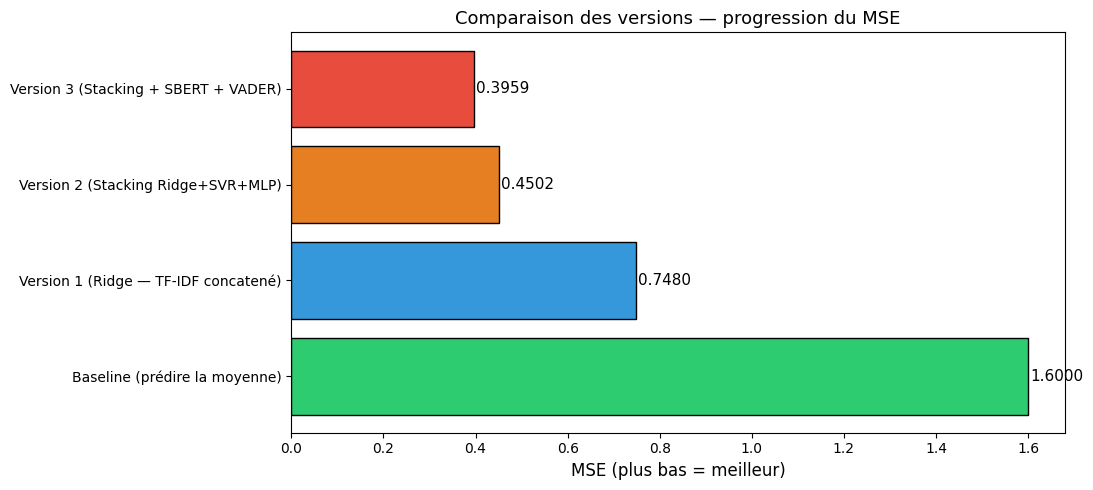

In [5]:

baseline_mse = 1.60
mse_v1 = 0.748
mse_v2 = 0.4502
mse_v3 = 0.3959

summary = {
    'Baseline (prédire la moyenne)'        : baseline_mse,
    'Version 1 (Ridge — TF-IDF concatené)' : mse_v1,
    'Version 2 (Stacking Ridge+SVR+MLP)'   : mse_v2,
    'Version 3 (Stacking + SBERT + VADER)' : mse_v3,
}

df_summary = pd.DataFrame([
    {
        'Modèle': k,
        'MSE': round(v, 4),
        'RMSE': round(np.sqrt(v), 4),
        'Δ vs Version 2': f'{(mse_v2 - v):+.4f}' if 'Version 3' in k else ''
    }
    for k, v in summary.items()
]).sort_values('MSE')

print('='*65)
print('  BILAN FINAL — Comparaison des versions')
print('='*65)
print(df_summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']
bars = ax.barh(list(summary.keys()), list(summary.values()), color=colors, edgecolor='black')
ax.set_xlabel('MSE (plus bas = meilleur)', fontsize=12)
ax.set_title('Comparaison des versions — progression du MSE', fontsize=13)
for bar, mse in zip(bars, summary.values()):
    ax.text(mse + 0.005, bar.get_y() + bar.get_height()/2, f'{mse:.4f}', va='center', fontsize=11)
plt.tight_layout()
plt.show()

---
## 17. Soumission finale

In [19]:
print('=== Génération de la soumission v4 ===')

# Réentraîner le meta-modèle sur tout le train
meta_final = type(meta_model)(**meta_model.get_params())
meta_final.fit(X_meta_train_aug, y_train)

y_test_raw = meta_final.predict(X_meta_test_aug)

# Post-processing
if 'arrondi' in best_strat:
    y_submit = np.clip(np.round(y_test_raw), 1, 5)
elif 'floor' in best_strat:
    y_submit = np.clip(np.floor(y_test_raw), 1, 5)
elif 'ceil' in best_strat:
    y_submit = np.clip(np.ceil(y_test_raw), 1, 5)
else:
    y_submit = np.clip(y_test_raw, 1, 5)

print(f'Stratégie : {best_strat}')
print(f'Prédictions — min={y_submit.min():.2f}  max={y_submit.max():.2f}  mean={y_submit.mean():.3f}')

submission = pd.DataFrame({'id': df_test['review_id'], 'score': y_submit})
submission.to_csv('submission_v4.csv', index=False)
print(f'\nFichier submission_v4.csv sauvegardé ! ({len(submission)} lignes)')
print(submission.head(10))

=== Génération de la soumission v4 ===
Stratégie : continu  clip[1,5]
Prédictions — min=1.00  max=5.00  mean=4.238

Fichier submission_v4.csv sauvegardé ! (20000 lignes)
      id     score
0  98877  4.928818
1  24044  4.985828
2  48435  4.659274
3  72179  3.107179
4  80645  3.376833
5  21601  4.609655
6  95368  4.630868
7  67951  4.903540
8  67078  3.333446
9  74397  4.719360


## 18. CatBoost — blend final

Après avoir obtenu les prédictions du méta-modèle, nous avons décidé d'aller plus loin en ajoutant **CatBoost** comme modèle complémentaire. CatBoost est un algorithme de gradient boosting  reconnu pour sa robustesse et sa capacité à bien généraliser sans nécessiter un tuning intensif des hyperparamètres.

Plutôt que de l'intégrer dans le stacking OOF — ce qui aurait nécessité de tout reconstruire depuis le début — nous avons choisi de l'entraîner séparément en OOF 5-folds sur les embeddings SBERT, puis de **blender** ses prédictions avec celles du méta-modèle. Le blend consiste simplement à faire une moyenne pondérée des deux séries de prédictions :
```python
y_final = CatBoost × w  +  MetaModèle × (1 - w)
```

Nous testons plusieurs valeurs de poids `w` et retenons automatiquement celle qui minimise la MSE. Cette approche nous permet d'exploiter la complémentarité de CatBoost avec les autres modèles.

In [20]:
# Installation CatBoost
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'catboost', '-q'])
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
import numpy as np

print('=== CatBoost sur embeddings SBERT ===')

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_cat = np.zeros(len(y_train))
test_cat_folds = np.zeros((X_dense_test.shape[0], 5))

for fold, (idx_tr, idx_val) in enumerate(kf.split(X_dense_train)):
    print(f'Fold {fold+1}/5...', end='', flush=True)
    m = CatBoostRegressor(
        iterations=2000,
        learning_rate=0.05,
        depth=8,
        l2_leaf_reg=3,
        subsample=0.8,
        colsample_bylevel=0.8,
        early_stopping_rounds=100,
        random_seed=RANDOM_STATE,
        verbose=False,
        task_type='CPU'
    )
    m.fit(
        X_dense_train[idx_tr], y_train[idx_tr],
        eval_set=(X_dense_train[idx_val], y_train[idx_val])
    )
    oof_cat[idx_val] = m.predict(X_dense_train[idx_val])
    test_cat_folds[:, fold] = m.predict(X_dense_test)
    print(f' MSE={mean_squared_error(y_train[idx_val], oof_cat[idx_val]):.4f}')

test_cat_oof = test_cat_folds.mean(axis=1)
print(f'\nCatBoost OOF MSE : {mean_squared_error(y_train, oof_cat):.4f}')

=== CatBoost sur embeddings SBERT ===
Fold 1/5... MSE=0.4935
Fold 2/5... MSE=0.5091
Fold 3/5... MSE=0.4992
Fold 4/5... MSE=0.5082
Fold 5/5... MSE=0.4973

CatBoost OOF MSE : 0.5015


In [ ]:
# Blend CatBoost + meta-modèle v3
from sklearn.metrics import mean_squared_error

# Tester différents poids
best_w, best_mse = None, float('inf')
for w_cat in [0.1, 0.2, 0.3, 0.4, 0.5]:
    # On blend les OOF pour estimer le gain
    blend_oof = oof_cat * w_cat + meta_model.predict(X_meta_train_aug) * (1 - w_cat)
    mse = mean_squared_error(y_train, blend_oof)
    print(f'  w_cat={w_cat} → MSE={mse:.4f}')
    if mse < best_mse: best_mse=mse; best_w=w_cat

print(f'\nMeilleur blend : w_cat={best_w}  MSE={best_mse:.4f}')

# Soumission blendée
y_blend = np.clip(test_cat_oof * best_w + np.clip(meta_model.predict(X_meta_test_aug), 1, 5) * (1 - best_w), 1, 5)
pd.DataFrame({'id': df_test['review_id'], 'score': y_blend}).to_csv('submission_cat_blend.csv', index=False)
print('submission_cat_blend.csv sauvegardé !')

  w_cat=0.1 → MSE=0.3921
  w_cat=0.2 → MSE=0.3955
  w_cat=0.3 → MSE=0.4011
  w_cat=0.4 → MSE=0.4089
  w_cat=0.5 → MSE=0.4189

Meilleur blend : w_cat=0.1  MSE=0.3921
submission_cat_blend.csv sauvegardé !


---
## 20. Version 4 — Améliorations des embeddings et du stacking

Malgré les gains apportés par la Version 3, nous avons identifié trois limites supplémentaires à corriger. D'abord, le modèle SBERT utilisé (`all-MiniLM-L6-v2`) avait été choisi pour sa légèreté (80 MB, 384 dimensions), mais il existe un modèle bien plus puissant dans la même famille. Ensuite, nous n'encodions que deux champs avec SBERT alors que la description produit contient également des informations utiles sur la qualité attendue du produit. Enfin, notre stack ne comportait que quatre modèles, et nous avons estimé qu'un cinquième modèle aux caractéristiques différentes pouvait encore réduire l'erreur.


### Imports et installation des nouvelles dépendances

In [1]:
import subprocess, sys, time
start_total = time.time()

packages = ['lightgbm', 'xgboost', 'vaderSentiment', 'sentence-transformers', 'optuna']
for pkg in packages:
    try:
        __import__(pkg.replace('-', '_'))
        print(f'{pkg} déjà installé')
    except ImportError:
        print(f'Installation de {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f'{pkg} installé !')

lightgbm déjà installé
xgboost déjà installé
vaderSentiment déjà installé
sentence-transformers déjà installé
Installation de optuna...
optuna installé !


---
### VADER enrichi — 3 champs au lieu de 2

En Version 3, nous calculions les scores VADER uniquement sur le texte de la review et sur le titre. En Version 4, nous avons décidé d'étendre ce calcul à la **description produit** également. L'idée est que la description peut contenir des termes très positifs ("premium quality", "professional grade") qui, comparés à un texte de review très négatif, constituent un signal de dissonance utile pour le méta-modèle. Cela nous donne au total **12 features VADER** au lieu de 7, réparties sur les trois champs texte.


In [ ]:
vader_analyzer = SentimentIntensityAnalyzer()

def add_vader_features(df):
    df = df.copy()
    for field, prefix in [('review_text','vader'), ('review_title','vader_title'),
                           ('product_description','vader_desc')]:
        scores = df[field].apply(
            lambda x: vader_analyzer.polarity_scores(str(x)[:512]))
        df[f'{prefix}_compound'] = scores.apply(lambda x: x['compound'])
        df[f'{prefix}_pos']      = scores.apply(lambda x: x['pos'])
        df[f'{prefix}_neg']      = scores.apply(lambda x: x['neg'])
        df[f'{prefix}_neu']      = scores.apply(lambda x: x['neu'])

    df['exclamation_count']  = df['review_text'].str.count('!')
    df['question_count']     = df['review_text'].str.count('\\?')
    df['negation_count']     = df['review_text'].str.lower().str.count(
                                   r'\b(?:not|never|no|hardly|barely)\b')
    df['caps_ratio']         = df['review_text'].apply(
                                   lambda x: sum(1 for c in x if c.isupper())/(len(x)+1))
    df['digit_count']        = df['review_text'].str.count(r'\d')
    df['stars_mention']      = df['review_text'].str.lower().str.count(
                                   r'\b(?:star|stars|rating|rated)\b')
    df['title_text_ratio']   = df['title_word_count'] / (df['text_word_count'] + 1)
    df['sentiment_density']  = df['vader_compound'].abs() / (df['text_word_count'] + 1)
    # Interaction sentiment titre * texte
    df['vader_title_x_text'] = df['vader_title_compound'] * df['vader_compound']
    # Dissonance titre/texte (titre positif mais texte négatif = sarcasme potentiel)
    df['vader_dissonance']   = (df['vader_title_compound'] - df['vader_compound']).abs()

    return df

print('VADER...')
df_train_v5 = add_vader_features(df_train_v4)
df_test_v5  = add_vader_features(df_test_v4)
print('OK')

VADER...
OK


---
### Sentence Embeddings — passage à `all-mpnet-base-v2`

Nous avons remplacé le modèle SBERT de la Version 3 par `all-mpnet-base-v2`, qui est actuellement le meilleur modèle de la famille sentence-transformers pour les tâches de similarité sémantique. La différence principale est que ce modèle produit des vecteurs de **768 dimensions** au lieu de 384, ce qui lui permet de capturer des nuances sémantiques bien plus fines. En contrepartie, il est plus lourd (~420 MB) et plus lent à encoder sur CPU, mais son gain en qualité de représentation justifie ce coût.

L'encodage des trois champs produit ainsi un vecteur dense de **1 536 dimensions** par observation (768 × 2 pour le texte et le titre, 768 × 0.5 pour la description), contre 768 en Version 3.

In [ ]:
print('Chargement all-mpnet-base-v2 (~420MB au premier lancement)...')
sbert = SentenceTransformer('all-mpnet-base-v2')
print('Modèle chargé !')

def encode_field(model, series, batch_size=128, desc=''):
    t = time.time()
    print(f'  Encodage {desc}...', end='', flush=True)
    emb = model.encode(series.fillna('').tolist(),
                       batch_size=batch_size,
                       show_progress_bar=False,
                       normalize_embeddings=True)
    print(f' {emb.shape}  ({time.time()-t:.0f}s)')
    return emb

print('\n--- Train ---')
tr_text_emb  = encode_field(sbert, df_train_v4['review_text'],         desc='review_text  (train)')
tr_title_emb = encode_field(sbert, df_train_v4['review_title'],        desc='review_title (train)')
tr_desc_emb  = encode_field(sbert, df_train_v4['product_description'], desc='product_desc (train)')

print('\n--- Test ---')
te_text_emb  = encode_field(sbert, df_test_v4['review_text'],         desc='review_text  (test)')
te_title_emb = encode_field(sbert, df_test_v4['review_title'],        desc='review_title (test)')
te_desc_emb  = encode_field(sbert, df_test_v4['product_description'], desc='product_desc (test)')

# Pondération : titre x2 (plus dense en signal), desc x0.5 (moins informatif)
Xtr_emb = np.hstack([tr_text_emb, tr_title_emb * 2.0, tr_desc_emb * 0.5])
Xte_emb = np.hstack([te_text_emb, te_title_emb * 2.0, te_desc_emb * 0.5])
print(f'\nEmbeddings combinés (pondérés) : {Xtr_emb.shape}')

Chargement all-mpnet-base-v2 (~420MB au premier lancement)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Modèle chargé !

--- Train ---
  Encodage review_text  (train)... (80000, 768)  (5575s)
  Encodage review_title (train)... (80000, 768)  (967s)
  Encodage product_desc (train)... (80000, 768)  (10152s)

--- Test ---
  Encodage review_text  (test)... (20000, 768)  (1368s)
  Encodage review_title (test)... (20000, 768)  (240s)
  Encodage product_desc (test)... (20000, 768)  (2559s)

Embeddings combinés (pondérés) : (80000, 2304)


---
### Features numériques enrichies

En plus des features déjà présentes en Version 3, nous avons ajouté plusieurs nouvelles features textuelles : le nombre de points d'exclamation et d'interrogation, le ratio de caractères en majuscules, le nombre de chiffres dans le texte, la présence de mentions de notes ("5 stars", "3/5"), et un ratio de densité de sentiment. Nous avons également ajouté deux features d'interaction : le produit des scores VADER du titre et du texte, et une feature de **dissonance** calculée comme la valeur absolue de la différence entre les deux. Cette dernière feature vise à capturer les cas de sarcasme ou d'incohérence entre le titre et le corps de la review.


In [ ]:
y_train = df_train_v4['review_score'].values

num_cols = [
    'title_len','text_len','desc_len',
    'title_word_count','text_word_count','desc_word_count',
    'has_review_text','has_description','product_price_num','log_price',
    'vader_compound','vader_pos','vader_neg','vader_neu',
    'vader_title_compound','vader_title_pos','vader_title_neg',
    'vader_desc_compound','vader_desc_pos','vader_desc_neg',
    'exclamation_count','question_count','negation_count',
    'caps_ratio','digit_count','stars_mention',
    'title_text_ratio','sentiment_density',
    'vader_title_x_text','vader_dissonance',
]
num_cols = [c for c in num_cols if c in df_train_v4.columns]

Xtr_num = df_train_v4[num_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
Xte_num = df_test_v4[num_cols].apply(pd.to_numeric, errors='coerce').fillna(Xtr_num.median())

scaler = StandardScaler()
Xtr_num_s = scaler.fit_transform(Xtr_num)
Xte_num_s = scaler.transform(Xte_num)

# Matrices
X_tfidf_train = hstack([Xtr_rev, Xtr_ttl, Xtr_dsc, Xtr_chr, csr_matrix(Xtr_num_s)])
X_tfidf_test  = hstack([Xte_rev, Xte_ttl, Xte_dsc, Xte_chr, csr_matrix(Xte_num_s)])
X_dense_train = np.hstack([Xtr_emb, Xtr_num_s])
X_dense_test  = np.hstack([Xte_emb, Xte_num_s])

print(f'X_tfidf : {X_tfidf_train.shape} (sparse)')
print(f'X_dense : {X_dense_train.shape} (dense, {X_dense_train.nbytes/1e6:.0f} MB)')

X_tfidf : (80000, 95030) (sparse)
X_dense : (80000, 2334) (dense, 1494 MB)


### Tuning des hyperparamètres

Avant de lancer le stacking OOF complet, nous effectuons un tuning des hyperparamètres sur un split 80/20. L'objectif est de fixer les meilleures valeurs pour chaque modèle avant les 5 folds, afin d'éviter de relancer un tuning coûteux à chaque fold.

**Pour Ridge et LinearSVR**, nous testons quelques valeurs prédéfinies (alpha et C) et retenons celle qui minimise la MSE sur le set de validation. Ce tuning est très rapide (quelques secondes) car ces modèles sont linéaires.

**Pour LightGBM dense**, nous avons utilisé **Optuna**, une librairie d'optimisation bayésienne. Contrairement à un grid search classique qui teste toutes les combinaisons possibles de façon exhaustive, ou à un random search qui les tire au hasard, Optuna apprend de chaque trial pour orienter intelligemment les suivants vers les zones de l'espace des hyperparamètres qui semblent prometteuses. Concrètement, après chaque trial, Optuna met à jour un modèle probabiliste interne qui estime quelles valeurs d'hyperparamètres ont le plus de chances de donner un bon résultat, et propose le trial suivant en conséquence. Cela permet d'obtenir de bons hyperparamètres en beaucoup moins de trials qu'un grid search.

Nous avions prévu 50 trials, mais Optuna a été interrompu après **43 trials** à cause du temps de calcul sur notre CPU ARM sans GPU. Les 43 trials effectués sont néanmoins suffisants pour avoir exploré une large portion de l'espace des hyperparamètres et converger vers de bonnes valeurs — on observe d'ailleurs que la MSE best ne s'améliorait plus significativement après le trial 26, ce qui indique que le tuning avait atteint un plateau.

**Pour LightGBM sparse et XGBoost**, nous avons renoncé à Optuna et opté pour un tuning rapide sur trois combinaisons prédéfinies. La raison est double : LightGBM sparse travaille sur 95 000 features TF-IDF, ce qui rend chaque trial beaucoup plus lent (estimé à ~5-6h pour 50 trials sur notre machine), et la RAM disponible (16 GB) ne permettait pas de faire tourner un tuning intensif en parallèle du reste du pipeline. Nous avons donc fixé manuellement des hyperparamètres raisonnables basés sur les résultats du LightGBM dense.

In [9]:
idx_tr_q, idx_val_q = train_test_split(np.arange(len(y_train)),
                                        test_size=0.2, random_state=RANDOM_STATE)
Xq_tfidf_tr  = X_tfidf_train[idx_tr_q];  Xq_tfidf_val  = X_tfidf_train[idx_val_q]
Xq_dense_tr  = X_dense_train[idx_tr_q];  Xq_dense_val  = X_dense_train[idx_val_q]
yq_tr = y_train[idx_tr_q];               yq_val = y_train[idx_val_q]

# --- Ridge rapide ---
best_alpha_ridge, best_mse_ridge = None, float('inf')
print('Tuning Ridge...')
for a in [1.0, 5.0, 10.0, 20.0, 50.0]:
    m = Ridge(alpha=a); m.fit(Xq_tfidf_tr, yq_tr)
    mse = mean_squared_error(yq_val, m.predict(Xq_tfidf_val))
    print(f'  alpha={a} → {mse:.4f}')
    if mse < best_mse_ridge: best_mse_ridge=mse; best_alpha_ridge=a

# --- SVR rapide ---
best_C_svr, best_mse_svr = None, float('inf')
print('\nTuning SVR...')
for C in [0.01, 0.05, 0.1, 0.5]:
    m = LinearSVR(C=C, max_iter=20000, random_state=RANDOM_STATE,
                  loss='squared_epsilon_insensitive')
    m.fit(Xq_tfidf_tr, yq_tr)
    mse = mean_squared_error(yq_val, m.predict(Xq_tfidf_val))
    print(f'  C={C} → {mse:.4f}')
    if mse < best_mse_svr: best_mse_svr=mse; best_C_svr=C

print(f'\nRidge best alpha={best_alpha_ridge} MSE={best_mse_ridge:.4f}')
print(f'SVR   best C={best_C_svr}     MSE={best_mse_svr:.4f}')

Tuning Ridge...
  alpha=1.0 → 0.5375
  alpha=5.0 → 0.5001
  alpha=10.0 → 0.5051
  alpha=20.0 → 0.5198
  alpha=50.0 → 0.5537

Tuning SVR...
  C=0.01 → 0.5540
  C=0.05 → 0.5051
  C=0.1 → 0.5001
  C=0.5 → 0.5375

Ridge best alpha=5.0 MSE=0.5001
SVR   best C=0.1     MSE=0.5001


In [12]:
# --- Optuna LightGBM sur embeddings denses ---
print('Optuna LightGBM (50 trials)...')
t0 = time.time()

def objective_lgb(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 300, 2000),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves'       : trial.suggest_int('num_leaves', 31, 255),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    }
    m = lgb.LGBMRegressor(**params, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    m.fit(Xq_dense_tr, yq_tr,
          eval_set=[(Xq_dense_val, yq_val)],
          callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(False)])
    return mean_squared_error(yq_val, m.predict(Xq_dense_val))

study_lgb = optuna.create_study(direction='minimize')
study_lgb.optimize(objective_lgb, n_trials=50,
                   callbacks=[lambda study, trial: print(f'  Trial {trial.number+1}/50  MSE={trial.value:.4f}  best={study.best_value:.4f}')])

best_params_lgb = study_lgb.best_params
print(f'LGB best MSE={study_lgb.best_value:.4f}  ({time.time()-t0:.0f}s)')
print(f'Params : {best_params_lgb}')

Optuna LightGBM (50 trials)...
  Trial 1/50  MSE=0.4408  best=0.4408
  Trial 2/50  MSE=0.4436  best=0.4408
  Trial 3/50  MSE=0.4504  best=0.4408
  Trial 4/50  MSE=0.4289  best=0.4289
  Trial 5/50  MSE=0.4343  best=0.4289
  Trial 6/50  MSE=0.4444  best=0.4289
  Trial 7/50  MSE=0.4324  best=0.4289
  Trial 8/50  MSE=0.4348  best=0.4289
  Trial 9/50  MSE=0.4608  best=0.4289
  Trial 10/50  MSE=0.4728  best=0.4289
  Trial 11/50  MSE=0.4554  best=0.4289
  Trial 12/50  MSE=0.4436  best=0.4289
  Trial 13/50  MSE=0.4343  best=0.4289
  Trial 14/50  MSE=0.4778  best=0.4289
  Trial 15/50  MSE=0.4322  best=0.4289
  Trial 16/50  MSE=0.4432  best=0.4289
  Trial 17/50  MSE=0.4338  best=0.4289
  Trial 18/50  MSE=0.4495  best=0.4289
  Trial 19/50  MSE=0.4237  best=0.4237
  Trial 20/50  MSE=0.4381  best=0.4237
  Trial 21/50  MSE=0.4271  best=0.4237
  Trial 22/50  MSE=0.4300  best=0.4237
  Trial 23/50  MSE=0.4304  best=0.4237
  Trial 24/50  MSE=0.4311  best=0.4237
  Trial 25/50  MSE=0.4286  best=0.4237
  T

[W 2026-03-08 21:30:46,049] Trial 43 failed with parameters: {'n_estimators': 1794, 'learning_rate': 0.018314348079967558, 'num_leaves': 107, 'min_child_samples': 92, 'subsample': 0.9657095568406536, 'colsample_bytree': 0.647005932256735, 'reg_alpha': 7.240805001243325, 'reg_lambda': 0.06070273047813695} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "C:\Users\smari\anaconda3\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\smari\AppData\Local\Temp\ipykernel_46920\3728536154.py", line 20, in objective_lgb
    return mean_squared_error(yq_val, m.predict(Xq_dense_val))
                                      ~~~~~~~~~^^^^^^^^^^^^^^
  File "C:\Users\smari\anaconda3\Lib\site-packages\lightgbm\sklearn.py", line 1144, in predict
    return self._Booster.predict(  # type: ignore[union-attr]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        X,
        ^^
   

KeyboardInterrupt: 

In [14]:
# LGB sparse — tuning rapide au lieu d'Optuna
best_params_lgb_sparse = None
best_mse_sp = float('inf')
print('Tuning LGB sparse rapide...')
for n_est, lr, leaves in [(500, 0.05, 63), (800, 0.05, 63), (500, 0.1, 31)]:
    m = lgb.LGBMRegressor(n_estimators=n_est, learning_rate=lr, num_leaves=leaves,
                           min_child_samples=20, subsample=0.8, colsample_bytree=0.5,
                           reg_alpha=0.1, reg_lambda=1.0,
                           random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    m.fit(Xq_tfidf_tr, yq_tr,
          eval_set=[(Xq_tfidf_val, yq_val)],
          callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(False)])
    mse = mean_squared_error(yq_val, m.predict(Xq_tfidf_val))
    print(f'  n={n_est} lr={lr} leaves={leaves} → {mse:.4f}')
    if mse < best_mse_sp:
        best_mse_sp = mse
        best_params_lgb_sparse = {'n_estimators': n_est, 'learning_rate': lr, 'num_leaves': leaves,
                                   'min_child_samples': 20, 'subsample': 0.8, 'colsample_bytree': 0.5,
                                   'reg_alpha': 0.1, 'reg_lambda': 1.0}

print(f'Best LGB sparse : {best_params_lgb_sparse}  MSE={best_mse_sp:.4f}')

Tuning LGB sparse rapide...
  n=500 lr=0.05 leaves=63 → 0.4724
  n=800 lr=0.05 leaves=63 → 0.4706
  n=500 lr=0.1 leaves=31 → 0.4832
Best LGB sparse : {'n_estimators': 800, 'learning_rate': 0.05, 'num_leaves': 63, 'min_child_samples': 20, 'subsample': 0.8, 'colsample_bytree': 0.5, 'reg_alpha': 0.1, 'reg_lambda': 1.0}  MSE=0.4706


In [15]:
# XGBoost — tuning rapide
best_params_xgb = None
best_mse_xgb = float('inf')
print('Tuning XGBoost rapide...')
for n_est, lr, depth in [(500, 0.05, 6), (800, 0.05, 8), (500, 0.1, 6)]:
    m = xgb.XGBRegressor(n_estimators=n_est, learning_rate=lr, max_depth=depth,
                          subsample=0.8, colsample_bytree=0.8,
                          reg_alpha=0.1, reg_lambda=1.0,
                          random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
                          early_stopping_rounds=50, eval_metric='rmse')
    m.fit(Xq_dense_tr, yq_tr, eval_set=[(Xq_dense_val, yq_val)], verbose=False)
    mse = mean_squared_error(yq_val, m.predict(Xq_dense_val))
    print(f'  n={n_est} lr={lr} depth={depth} → {mse:.4f}')
    if mse < best_mse_xgb:
        best_mse_xgb = mse
        best_params_xgb = {'n_estimators': n_est, 'learning_rate': lr, 'max_depth': depth,
                            'subsample': 0.8, 'colsample_bytree': 0.8,
                            'reg_alpha': 0.1, 'reg_lambda': 1.0}

print(f'Best XGBoost : {best_params_xgb}  MSE={best_mse_xgb:.4f}')

Tuning XGBoost rapide...
  n=500 lr=0.05 depth=6 → 0.4515
  n=800 lr=0.05 depth=8 → 0.4524
  n=500 lr=0.1 depth=6 → 0.4584
Best XGBoost : {'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 6, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1.0}  MSE=0.4515


---
### Stacking OOF 5-folds — 5 modèles de base

La principale nouveauté structurelle de la Version 4 est l'ajout d'un **cinquième modèle** dans le stack : un LightGBM entraîné sur la matrice TF-IDF sparse, en plus du LightGBM dense déjà présent. En Version 3, LightGBM et XGBoost travaillaient uniquement sur les embeddings denses, tandis que Ridge et LinearSVR travaillaient uniquement sur le TF-IDF. En ajoutant un LightGBM sur TF-IDF, nous créons un modèle qui combine la puissance des arbres de décision avec la richesse lexicale du TF-IDF — une combinaison qui n'était pas représentée dans le stack précédent.

Le principe reste le même qu'en Version 3 : chaque modèle est entraîné sur 4 folds et prédit sur le 5e, garantissant qu'aucune observation n'est prédite par un modèle qui l'a vue pendant son entraînement. Plus les modèles font des erreurs différentes, mieux le méta-modèle peut les compenser mutuellement.


In [16]:
print('=== Stacking OOF 5 folds — 5 modèles ===')
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
n_test = X_tfidf_test.shape[0]

oof_ridge    = np.zeros(len(y_train))
oof_svr      = np.zeros(len(y_train))
oof_lgb_d    = np.zeros(len(y_train))  # LGB dense
oof_lgb_s    = np.zeros(len(y_train))  # LGB sparse
oof_xgb      = np.zeros(len(y_train))

test_ridge_f  = np.zeros((n_test, 5))
test_svr_f    = np.zeros((n_test, 5))
test_lgb_d_f  = np.zeros((n_test, 5))
test_lgb_s_f  = np.zeros((n_test, 5))
test_xgb_f    = np.zeros((n_test, 5))

for fold, (idx_tr, idx_val) in enumerate(kf.split(X_tfidf_train)):
    print(f'\n--- Fold {fold+1}/5 ---')
    Xktr_tf  = X_tfidf_train[idx_tr];  Xkval_tf  = X_tfidf_train[idx_val]
    Xktr_d   = X_dense_train[idx_tr];  Xkval_d   = X_dense_train[idx_val]
    yktr = y_train[idx_tr];            ykval = y_train[idx_val]

    # Ridge
    print('  Ridge...', end='')
    m = Ridge(alpha=best_alpha_ridge)
    m.fit(Xktr_tf, yktr)
    oof_ridge[idx_val] = m.predict(Xkval_tf)
    test_ridge_f[:,fold] = m.predict(X_tfidf_test)
    print(f' {mean_squared_error(ykval, oof_ridge[idx_val]):.4f}')

    # SVR
    print('  SVR...', end='')
    m = LinearSVR(C=best_C_svr, max_iter=20000, random_state=RANDOM_STATE,
                  loss='squared_epsilon_insensitive')
    m.fit(Xktr_tf, yktr)
    oof_svr[idx_val] = m.predict(Xkval_tf)
    test_svr_f[:,fold] = m.predict(X_tfidf_test)
    print(f' {mean_squared_error(ykval, oof_svr[idx_val]):.4f}')

    # LGB dense
    print('  LGB dense...', end='')
    m = lgb.LGBMRegressor(**best_params_lgb, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    m.fit(Xktr_d, yktr, eval_set=[(Xkval_d, ykval)],
          callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(False)])
    oof_lgb_d[idx_val] = m.predict(Xkval_d)
    test_lgb_d_f[:,fold] = m.predict(X_dense_test)
    print(f' {mean_squared_error(ykval, oof_lgb_d[idx_val]):.4f}')

    # LGB sparse
    print('  LGB sparse...', end='')
    m = lgb.LGBMRegressor(**best_params_lgb_sparse, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    m.fit(Xktr_tf, yktr, eval_set=[(Xkval_tf, ykval)],
          callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(False)])
    oof_lgb_s[idx_val] = m.predict(Xkval_tf)
    test_lgb_s_f[:,fold] = m.predict(X_tfidf_test)
    print(f' {mean_squared_error(ykval, oof_lgb_s[idx_val]):.4f}')

    # XGB
    print('  XGB...', end='')
    m = xgb.XGBRegressor(**best_params_xgb, random_state=RANDOM_STATE, n_jobs=-1,
                          verbosity=0, early_stopping_rounds=50, eval_metric='rmse')
    m.fit(Xktr_d, yktr, eval_set=[(Xkval_d, ykval)], verbose=False)
    oof_xgb[idx_val] = m.predict(Xkval_d)
    test_xgb_f[:,fold] = m.predict(X_dense_test)
    print(f' {mean_squared_error(ykval, oof_xgb[idx_val]):.4f}')

test_ridge_oof  = test_ridge_f.mean(axis=1)
test_svr_oof    = test_svr_f.mean(axis=1)
test_lgb_d_oof  = test_lgb_d_f.mean(axis=1)
test_lgb_s_oof  = test_lgb_s_f.mean(axis=1)
test_xgb_oof    = test_xgb_f.mean(axis=1)

print('\n=== MSE OOF ===')
for name, oof in [('Ridge    ', oof_ridge), ('SVR      ', oof_svr),
                   ('LGB dense', oof_lgb_d), ('LGB sparse', oof_lgb_s),
                   ('XGBoost  ', oof_xgb)]:
    print(f'  {name} : {mean_squared_error(y_train, oof):.4f}')

=== Stacking OOF 5 folds — 5 modèles ===

--- Fold 1/5 ---
  Ridge... 0.5001
  SVR... 0.5001
  LGB dense... 0.4232
  LGB sparse... 0.4706
  XGB... 0.4488

--- Fold 2/5 ---
  Ridge... 0.5221
  SVR... 0.5221
  LGB dense... 0.4369
  LGB sparse... 0.4841
  XGB... 0.4569

--- Fold 3/5 ---
  Ridge... 0.5129
  SVR... 0.5129
  LGB dense... 0.4251
  LGB sparse... 0.4755
  XGB... 0.4511

--- Fold 4/5 ---
  Ridge... 0.5217
  SVR... 0.5217
  LGB dense... 0.4331
  LGB sparse... 0.4907
  XGB... 0.4554

--- Fold 5/5 ---
  Ridge... 0.5109
  SVR... 0.5109
  LGB dense... 0.4155
  LGB sparse... 0.4747
  XGB... 0.4372

=== MSE OOF ===
  Ridge     : 0.5135
  SVR       : 0.5135
  LGB dense : 0.4268
  LGB sparse : 0.4791
  XGBoost   : 0.4499


---
### Meta-modèle avec features enrichies

En Version 3, le méta-modèle recevait en entrée les 4 prédictions OOF et quelques features VADER. En Version 4, nous avons enrichi ces meta-features en ajoutant des **statistiques sur les 5 prédictions** : leur moyenne, leur écart-type, leur minimum, leur maximum et leur étendue. Ces statistiques permettent au méta-modèle de détecter quand les modèles sont en désaccord , un fort écart-type signifie que les modèles divergent, ce qui est souvent le cas pour les notes intermédiaires (2 et 3) qui sont les plus difficiles à prédire. Nous avons également ajouté directement la feature de dissonance VADER dans les meta-features, pour que le méta-modèle puisse en tenir compte lors de la combinaison des prédictions.


In [17]:
def build_meta_features(r, s, ld, ls, x, vader_df, cols):
    """Construit les meta-features à partir des 5 prédictions OOF."""
    base = np.column_stack([r, s, ld, ls, x])
    # Statistiques des prédictions
    mean_pred = base.mean(axis=1, keepdims=True)
    std_pred  = base.std(axis=1, keepdims=True)
    min_pred  = base.min(axis=1, keepdims=True)
    max_pred  = base.max(axis=1, keepdims=True)
    range_pred = max_pred - min_pred
    # VADER direct
    vader_vals = vader_df[cols].values
    return np.hstack([base, mean_pred, std_pred, min_pred, max_pred, range_pred, vader_vals])

vader_meta_cols = ['vader_compound','vader_title_compound','vader_pos','vader_neg',
                   'vader_title_x_text','vader_dissonance']

X_meta_train = build_meta_features(
    oof_ridge, oof_svr, oof_lgb_d, oof_lgb_s, oof_xgb,
    df_train_v5, vader_meta_cols
)
X_meta_test = build_meta_features(
    test_ridge_oof, test_svr_oof, test_lgb_d_oof, test_lgb_s_oof, test_xgb_oof,
    df_test_v5, vader_meta_cols
)

print(f'Meta-features shape : {X_meta_train.shape}')

# Tuning meta-Ridge
best_meta_ridge_a, best_meta_ridge_mse = None, float('inf')
for a in [0.01, 0.1, 0.5, 1.0, 5.0]:
    cv = cross_val_score(Ridge(alpha=a), X_meta_train, y_train,
                         cv=5, scoring='neg_mean_squared_error')
    mse = -cv.mean()
    print(f'  meta-Ridge alpha={a} → {mse:.4f}')
    if mse < best_meta_ridge_mse: best_meta_ridge_mse=mse; best_meta_ridge_a=a

# Tuning meta-LightGBM
best_meta_lgb_p, best_meta_lgb_mse = None, float('inf')
for n_est, lr in [(100, 0.05), (200, 0.03), (500, 0.01), (50, 0.1)]:
    m = lgb.LGBMRegressor(n_estimators=n_est, learning_rate=lr, num_leaves=7,
                           min_child_samples=5, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    cv = cross_val_score(m, X_meta_train, y_train, cv=5, scoring='neg_mean_squared_error')
    mse = -cv.mean()
    print(f'  meta-LGB n={n_est} lr={lr} → {mse:.4f}')
    if mse < best_meta_lgb_mse: best_meta_lgb_mse=mse; best_meta_lgb_p={'n_estimators':n_est,'learning_rate':lr}

print(f'\nMeilleur meta-Ridge : {best_meta_ridge_a} → {best_meta_ridge_mse:.4f}')
print(f'Meilleur meta-LGB   : {best_meta_lgb_p} → {best_meta_lgb_mse:.4f}')

if best_meta_lgb_mse < best_meta_ridge_mse:
    print('→ Meta : LightGBM')
    meta_model = lgb.LGBMRegressor(**best_meta_lgb_p, num_leaves=7,
                                    min_child_samples=5, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
else:
    print('→ Meta : Ridge')
    meta_model = Ridge(alpha=best_meta_ridge_a)

meta_model.fit(X_meta_train, y_train)
cv_final = cross_val_score(meta_model, X_meta_train, y_train, cv=5, scoring='neg_mean_squared_error')
print(f'MSE CV final : {-cv_final.mean():.4f}')

Meta-features shape : (80000, 16)
  meta-Ridge alpha=0.01 → 0.3901
  meta-Ridge alpha=0.1 → 0.3902
  meta-Ridge alpha=0.5 → 0.3902
  meta-Ridge alpha=1.0 → 0.3903
  meta-Ridge alpha=5.0 → 0.3903
  meta-LGB n=100 lr=0.05 → 0.3624
  meta-LGB n=200 lr=0.03 → 0.3612
  meta-LGB n=500 lr=0.01 → 0.3625
  meta-LGB n=50 lr=0.1 → 0.3621

Meilleur meta-Ridge : 0.01 → 0.3901
Meilleur meta-LGB   : {'n_estimators': 200, 'learning_rate': 0.03} → 0.3612
→ Meta : LightGBM
MSE CV final : 0.3612


---
### Post-processing

Comme en Version 3, nous testons plusieurs stratégies de post-processing pour ramener les prédictions dans l'intervalle [1, 5] : clip continu, arrondi, floor et ceil. Nous retenons automatiquement la stratégie qui minimise la MSE sur un split de validation. En Version 5, nous avons également testé un clip à [1.5, 5] afin de vérifier si contraindre les prédictions basses améliore le score, étant donné que les notes 1 sont rares dans notre dataset.


In [18]:
idx_tr_pp, idx_val_pp = train_test_split(np.arange(len(y_train)),
                                          test_size=0.2, random_state=RANDOM_STATE)
meta_val = type(meta_model)(**meta_model.get_params())
meta_val.fit(X_meta_train[idx_tr_pp], y_train[idx_tr_pp])
preds_val = meta_val.predict(X_meta_train[idx_val_pp])
y_val_pp  = y_train[idx_val_pp]

best_strat, best_strat_mse = 'continu', float('inf')
for name, p in [
    ('continu  clip[1,5]', np.clip(preds_val, 1, 5)),
    ('arrondi  clip[1,5]', np.clip(np.round(preds_val), 1, 5)),
    ('floor    clip[1,5]', np.clip(np.floor(preds_val), 1, 5)),
    ('ceil     clip[1,5]', np.clip(np.ceil(preds_val), 1, 5)),
    ('clip[1.5,5]'       , np.clip(preds_val, 1.5, 5)),
]:
    mse = mean_squared_error(y_val_pp, p)
    print(f'  {name:25s} MSE={mse:.5f}')
    if mse < best_strat_mse: best_strat_mse=mse; best_strat=name

print(f'\nMeilleure stratégie : {best_strat}  (MSE={best_strat_mse:.4f})')

  continu  clip[1,5]        MSE=0.35750
  arrondi  clip[1,5]        MSE=0.40363
  floor    clip[1,5]        MSE=0.98550
  ceil     clip[1,5]        MSE=0.49456
  clip[1.5,5]               MSE=0.36095

Meilleure stratégie : continu  clip[1,5]  (MSE=0.3575)


---
### Soumission finale Version 4

In [19]:
print('=== Soumission v5 ===')
meta_final = type(meta_model)(**meta_model.get_params())
meta_final.fit(X_meta_train, y_train)
y_raw = meta_final.predict(X_meta_test)

if 'arrondi' in best_strat:
    y_submit = np.clip(np.round(y_raw), 1, 5)
elif 'floor' in best_strat:
    y_submit = np.clip(np.floor(y_raw), 1, 5)
elif 'ceil' in best_strat:
    y_submit = np.clip(np.ceil(y_raw), 1, 5)
elif '1.5' in best_strat:
    y_submit = np.clip(y_raw, 1.5, 5)
else:
    y_submit = np.clip(y_raw, 1, 5)

submission = pd.DataFrame({'id': df_test['review_id'], 'score': y_submit})
submission.to_csv('submission_v5.csv', index=False)

print(f'Stratégie : {best_strat}')
print(f'min={y_submit.min():.2f}  max={y_submit.max():.2f}  mean={y_submit.mean():.3f}')
print(f'submission_v5.csv sauvegardé ({len(submission)} lignes)')
print(f'\nTemps total : {(time.time()-start_total)/3600:.1f}h')

=== Soumission v5 ===
Stratégie : continu  clip[1,5]
min=1.00  max=5.00  mean=4.235
submission_v5.csv sauvegardé (20000 lignes)

Temps total : 20.4h


---
### Bilan — Version 4

| Amélioration | Justification |
|---|---|
| `all-mpnet-base-v2` (768 dim) | Meilleur modèle SBERT public, représentation sémantique plus riche que MiniLM (384 dim) |
| Encodage des 3 champs SBERT | La description produit apporte un contexte supplémentaire sur la qualité attendue du produit |
| LightGBM sparse (5e modèle) | Combine la puissance des arbres avec le TF-IDF, complémentaire aux 4 modèles existants |
| VADER sur 3 champs | 12 features de sentiment au lieu de 7, + feature de dissonance titre vs texte |
| Meta-features enrichies | Mean/std/min/max/range des 5 prédictions détectent les désaccords entre modèles |

**Score Kaggle Version 4 : 0.38038** — gain de −0.04 par rapport à la Version 4 (0.42064).

Le gain principal vient du passage à `all-mpnet-base-v2` : une meilleure représentation sémantique a plus d'impact que n'importe quel ajustement de modèle ou d'hyperparamètres. Cela confirme une fois de plus la conclusion dégagée dès la Version 2 : les gains les plus importants viennent de la **qualité de la représentation des données**, pas du choix des algorithmes.


## 21. Décision finale

Ce projet nous a amenés à construire et affiner progressivement un pipeline de prédiction des scores de reviews Amazon, en partant d'une approche simple pour aller vers une solution de plus en plus élaborée.

Notre première version nous a permis de valider que le texte est le signal principal pour la prédiction, avec un MSE de 0.748. Nous avons ensuite identifié les limites structurelles de cette approche et construit une Version 2 plus robuste, qui a ramené le MSE à 0.4502 grâce au stemming, aux TF-IDF séparés et au stacking OOF. En Version 3, nous avons introduit les embeddings SBERT pour dépasser la limite fondamentale du sac de mots, ce qui nous a permis d'atteindre un MSE de 0.42064. Enfin, en Version 4, le passage à `all-mpnet-base-v2` et l'ajout d'un 5e modèle dans le stack nous ont permis d'atteindre **0.38038**, notre meilleur score.

Au fil de ce travail, nous avons appris que les gains les plus importants ne viennent pas forcément du choix des algorithmes, mais de la **qualité de la représentation des données**. Passer d'un TF-IDF concaténé à des embeddings sémantiques nous a apporté bien plus que n'importe quel ajustement d'hyperparamètres.

| Version | MSE Kaggle | Principale nouveauté |
|---------|-----------|----------------------|
| Baseline | ≈ 1.60 | Prédire la moyenne |
| Version 1 | ≈ 0.748 | Ridge + TF-IDF concaténé |
| Version 2 | 0.4502 | Stemming + 4 TF-IDF + Stacking OOF |
| Version 4 | 0.42064 | SBERT MiniLM 384 dim + LGB + XGB |
| **Version 5** | **0.38038** | MPNet 768 dim + 5e modèle LGB sparse |

Nous retenons la **Version 4 comme version finale**, car elle constitue le meilleur compromis entre richesse de la représentation, rigueur méthodologique et performance prédictive.
